<a href="https://colab.research.google.com/github/leejungp2/dl-study/blob/main/260517_04_pytorch_custom_datasets_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/04_pytorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[View Source Code](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/04_pytorch_custom_datasets.ipynb) | [View Slides](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/slides/04_pytorch_custom_datasets.pdf) | [Watch Video Walkthrough](https://youtu.be/Z_ikDlimN6A?t=71010)

# 04. PyTorch Custom Datasets


### 이전 내용 요약

- 이전 노트북(03)에서는  
  - PyTorch의 내장 데이터셋인 **FashionMNIST**를 사용하여  
  - 컴퓨터 비전 모델을 만드는 방법을 학습

### 머신러닝의 공통적인 흐름

- 대부분의 머신러닝 문제는 다음과 같은 단계로 진행됨

  1. 데이터셋 찾기
  2. 데이터를 숫자 형태로 변환
  3. 모델 구축 (또는 기존 모델 활용)
  4. 데이터의 패턴을 학습하여 예측 수행

### PyTorch의 데이터셋

- PyTorch는 다양한 머신러닝 벤치마크를 위한  
  **내장 데이터셋**을 제공

- 하지만 실제 프로젝트에서는  
  → **자신만의 커스텀 데이터셋(Custom Dataset)**을 사용하는 경우가 많음

## What is a custom dataset?

- 특정 문제 해결을 위해 사용되는 데이터의 집합
- 매우 유연한 개념으로, 거의 모든 형태의 데이터 포함 가능

### 개념 설명

- 커스텀 데이터셋은 다양한 형태로 구성될 수 있음
- 문제 유형에 따라 데이터의 형태가 달라짐

### 예시

- 음식 이미지 분류 앱 (예: Nutrify)
  - 데이터셋: 음식 이미지

- 리뷰 감성 분석 모델
  - 데이터셋: 고객 리뷰 + 평점

- 소리 분류 앱
  - 데이터셋: 소리 샘플 + 라벨

- 추천 시스템
  - 데이터셋: 사용자 구매 데이터

### PyTorch에서의 지원

- PyTorch는 다양한 도메인 라이브러리를 통해 데이터셋 로딩 기능 제공

  - TorchVision: 이미지 데이터
  - TorchText: 텍스트 데이터
  - TorchAudio: 오디오 데이터
  - TorchRec: 추천 시스템 데이터

### 한계 및 해결 방법

- 기본 제공 함수만으로는 부족할 수 있음

- 해결 방법
  - torch.utils.data.Dataset을 상속하여
  - 원하는 형태로 커스텀 데이터셋을 직접 구현 가능

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pytorch-domain-libraries.png" alt="different pytorch domain libraries can be used for specific PyTorch problems" width=1000/>

*PyTorch includes many existing functions to load in various custom datasets in the [`TorchVision`](https://pytorch.org/vision/stable/index.html), [`TorchText`](https://pytorch.org/text/stable/index.html), [`TorchAudio`](https://pytorch.org/audio/stable/index.html) and [`TorchRec`](https://pytorch.org/torchrec/) domain libraries.*

But sometimes these existing functions may not be enough.

In that case, we can always subclass `torch.utils.data.Dataset` and customize it to our liking.

## What we're going to cover

We're going to be applying the PyTorch Workflow we covered in [notebook 01](https://www.learnpytorch.io/01_pytorch_workflow/) and [notebook 02](https://www.learnpytorch.io/02_pytorch_classification/) to a computer vision problem.

- PyTorch Workflow (notebook 01, 02)를  
  컴퓨터 비전 문제에 적용

- 내장 데이터셋 대신  
  피자, 스테이크, 스시 이미지로 구성된  
  커스텀 데이터셋 사용

- 목표
  - 이미지 데이터 로드
  - 모델 학습
  - 이미지 분류 예측 수행

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pytorch-food-vision-layout.png" alt="building a pipeline to load in food images and then building a pytorch model to classify those food images" width=800 />


### 전체 흐름

- torchvision.datasets + 커스텀 Dataset 클래스 활용
- 음식 이미지를 로드하고
- PyTorch 모델을 만들어 분류 수행

Specifically, we're going to cover:

| **Topic** | **Contents** |
| ----- | ----- |
| **0. Importing PyTorch and setting up device-agnostic code** | Let's get PyTorch loaded and then follow best practice to setup our code to be device-agnostic.  |
| **1. Get data** | We're going to be using our own **custom dataset** of pizza, steak and sushi images. |
| **2. Become one with the data (data preparation)** | At the beginning of any new machine learning problem, it's paramount to understand the data you're working with. Here we'll take some steps to figure out what data we have. |
| **3. Transforming data** |Often, the data you get won't be 100% ready to use with a machine learning model, here we'll look at some steps we can take to *transform* our images so they're ready to be used with a model. |
| **4. Loading data with `ImageFolder` (option 1)** | PyTorch has many in-built data loading functions for common types of data. `ImageFolder` is helpful if our images are in standard image classification format. |
| **5. Loading image data with a custom `Dataset`** | What if PyTorch didn't have an in-built function to load data with? This is where we can build our own custom subclass of `torch.utils.data.Dataset`. |
| **6. Other forms of transforms (data augmentation)** | Data augmentation is a common technique for expanding the diversity of your training data. Here we'll explore some of `torchvision`'s in-built data augmentation functions. |
| **7. Model 0: TinyVGG without data augmentation** | By this stage, we'll have our data ready, let's build a model capable of fitting it. We'll also create some training and testing functions for training and evaluating our model. |
| **8. Exploring loss curves** | Loss curves are a great way to see how your model is training/improving over time. They're also a good way to see if your model is **underfitting** or **overfitting**. |
| **9. Model 1: TinyVGG with data augmentation** | By now, we've tried a model *without*, how about we try one *with* data augmentation? |
| **10. Compare model results** | Let's compare our different models' loss curves and see which performed better and discuss some options for improving performance. |
| **11. Making a prediction on a custom image** | Our model is trained to on a dataset of pizza, steak and sushi images. In this section we'll cover how to use our trained model to predict on an image *outside* of our existing dataset. |

## Where can can you get help?

All of the materials for this course [live on GitHub](https://github.com/mrdbourke/pytorch-deep-learning).

If you run into trouble, you can ask a question on the course [GitHub Discussions page](https://github.com/mrdbourke/pytorch-deep-learning/discussions) there too.

And of course, there's the [PyTorch documentation](https://pytorch.org/docs/stable/index.html) and [PyTorch developer forums](https://discuss.pytorch.org/), a very helpful place for all things PyTorch.

## 0. Importing PyTorch and setting up device-agnostic code

In [ ]:
import torch
from torch import nn

# Note: this notebook requires torch >= 1.10.0 (버전 확인)
torch.__version__

'2.10.0+cpu'

**Device-agnostic 코드 설정**

- 다양한 환경(CPU, GPU)에서 동일하게 동작하도록 코드 작성
- PyTorch에서는 device 설정을 통해 쉽게 처리 가능

> 참고 사항 (Google Colab 사용 시)

- GPU가 활성화되어 있지 않다면 다음 경로로 설정

  - Runtime → Change runtime type → Hardware accelerator → GPU

- GPU를 켜면 런타임이 초기화될 수 있음

  - 이 경우 이전 셀들을 다시 실행해야 함
  - Runtime → Run before 사용

In [ ]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device
## 현재 실행 환경에서 GPU를 사용할 수 있는지 확인한 뒤 사용할 장치를 결정

'cpu'

### **1. Get data**


- 모델 학습을 위해 먼저 데이터가 필요

- 요리 프로그램처럼 이미 일부 데이터는 준비된 상태에서 시작

**접근 방식**
- 처음부터 큰 모델이나 큰 데이터셋을 사용하지 않음
- 머신러닝은 반복적인 과정
  - 작은 규모로 시작
  - 동작 확인
  - 필요 시 점진적으로 확장

**사용할 데이터셋**
- [Food101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/)의 일부 사용

- 특징
  - 101가지 음식 클래스
  - 총 101,000장의 이미지
    - 학습: 75,750장
    - 테스트: 25,250장

**문제 설정**
- 101개의 음식 분류 문제를 해결하는 것은 가능함
- 이를 해결하는 방법
  - 머신러닝 모델 사용
  - 특히 PyTorch 기반 컴퓨터 비전 모델 ([notebook 03](https://www.learnpytorch.io/03_pytorch_computer_vision/))

**이번 실습 설정**
- 전체 101개 클래스 대신 3개만 사용
  - pizza
  - steak
  - sushi

- 각 클래스당 1000장 대신
  - 약 10%만 사용

**데이터 출처**

- Original [Food101 dataset and paper website](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/)
- [`torchvision.datasets.Food101`](https://pytorch.org/vision/main/generated/torchvision.datasets.Food101.html)
- [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb)
- [`data/pizza_steak_sushi.zip`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi.zip)

**다음 단계**

- GitHub에서 전처리된 데이터 다운로드 코드 작성 예정

**Note**

- 현재 데이터셋은 이미 전처리된 상태
- 실제 프로젝트에서는
  - 데이터 전처리를 직접 수행하는 경우가 많음

In [ ]:
import requests
import zipfile
from pathlib import Path

# 데이터 경로 설정
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# 폴더 존재 여부 확인
if image_path.is_dir(): # 해당 경로가 실제 디렉토리인지
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True) # 폴더 없으면 새로 생성

    # Download pizza, steak, sushi data
    ## github url에서 zip 파일 다운로드. 결과는 request 객체에 저장됨.
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    ## zip_ref = 압축 파일 객체
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


### 2. Become one with the data (data preparation)

- 데이터 다운로드 완료
- 이제 데이터를 이해하는 단계 진행

**데이터 준비의 중요성**

- 모델을 만들기 전에 반드시 필요한 단계
- 데이터에 대한 이해 없이 모델을 만들면 성능 저하 가능

- 핵심 질문
  - 내가 해결하려는 문제는 무엇인가?
  - 데이터는 어떤 구조를 가지고 있는가?

**참고 인용**

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-abraham-lossfunction.png" alt="tweet by mrdbourke, if I had eight hours to build a machine learning model, I'd spend the first 6 hours preparing my dataset" width=800/>

- 데이터 준비는 매우 중요함
- 출처: [@mrdbourke Twitter](https://twitter.com/mrdbourke)

**현재 데이터 상황**

- pizza, steak, sushi 이미지 데이터 보유
- 표준 이미지 분류 형식으로 구성됨

**이미지 분류 데이터 구조**

- 클래스별로 폴더가 분리되어 있음
  - 각 폴더 이름 = 클래스 이름

- 예시
  - `pizza/` 폴더 → pizza 이미지들
  - `steak/` 폴더 → steak 이미지들
  - `sushi/` 폴더 → sushi 이미지들

**데이터 디렉토리 구조**


In [ ]:
import os
def walk_through_dir(dir_path):
  """
  특정 디렉토리를 순회하며 내부 내용을 확인함
  Args:
    dir_path (str or pathlib.Path): 탐색 대상 디렉토리

  Returns:
    A print out of:
      하위 디렉토리 개수
      파일 개수
      현재 디렉토리 경로
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [ ]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.


**데이터 개수 확인**

- 클래스별 학습 이미지가 약 75장씩 존재
- 클래스별 테스트 이미지가 약 25장씩 존재

- 현재 단계에서는 시작하기에 충분한 양의 데이터

**참고 사항**

- 이 이미지들은 원본 [Food101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/)의 일부(subset)임
- 생성 과정은 [data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb)에서 확인 가능

**다음 단계**

- 학습 데이터 경로와 테스트 데이터 경로 설정
- 이후 데이터 로딩 및 전처리에 활용 예정

In [ ]:
# Setup train and testing paths
## 경로 생성
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualize an image

- 데이터 구조를 확인했으므로 이제 이미지를 직접 시각화할 차례

- 데이터 탐색의 핵심은 **계속 보고, 확인하는 것 (visualize)**

**목표**

- 다음 작업을 수행하는 코드 작성

1. [`pathlib.Path.glob()`](https://docs.python.org/3/library/pathlib.html#pathlib.Path.glob)을 사용하여  
   `.jpg` 파일 경로 모두 가져오기

2. [`random.choice()`](https://docs.python.org/3/library/random.html#random.choice)를 사용하여  
   랜덤 이미지 하나 선택

3. [`pathlib.Path.parent.stem`](https://docs.python.org/3/library/pathlib.html#pathlib.PurePath.parent)을 사용하여  
   이미지 클래스 이름 추출

4. [`PIL.Image.open()`](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.open)을 사용하여  
   이미지 열기  
   - PIL = Python Image Library

5. 이미지 출력 및 메타데이터 확인

Random image path: data/pizza_steak_sushi/test/steak/894825.jpg
Image class: steak
Image height: 512
Image width: 512


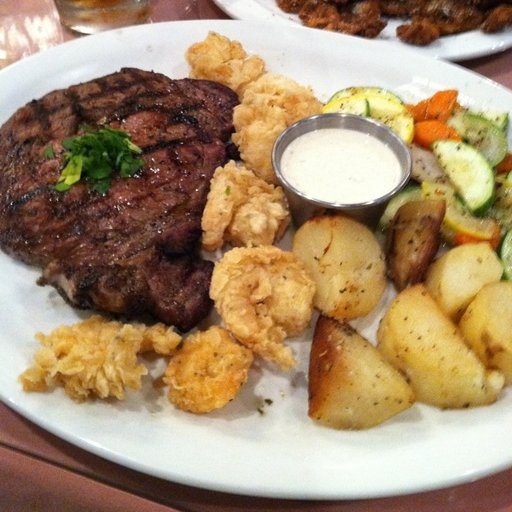

In [ ]:
import random
from PIL import Image

# Set seed
random.seed(42) # <- try changing this and see what happens

# 1. Get all image paths (* means "any combination")
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

We can do the same with [`matplotlib.pyplot.imshow()`](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.imshow.html), except we have to convert the image to a NumPy array first.

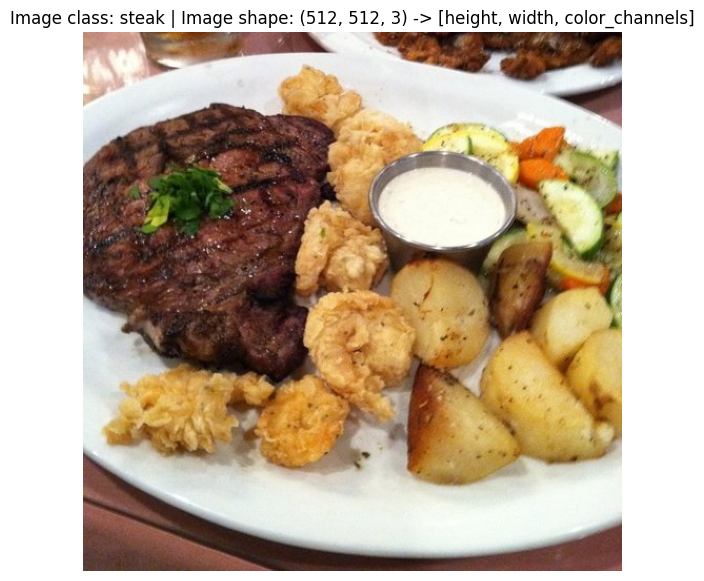

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

## 3. Transforming data

Now what if we wanted to load our image data into PyTorch?

Before we can use our image data with PyTorch we need to:

1. Turn it into tensors (numerical representations of our images).
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we'll call these `Dataset` and `DataLoader` for short.

There are several different kinds of pre-built datasets and dataset loaders for PyTorch, depending on the problem you're working on.

| **Problem space** | **Pre-built Datasets and Functions** |
| ----- | ----- |
| **Vision** | [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) |
| **Audio** | [`torchaudio.datasets`](https://pytorch.org/audio/stable/datasets.html) |
| **Text** | [`torchtext.datasets`](https://pytorch.org/text/stable/datasets.html) |
| **Recommendation system** | [`torchrec.datasets`](https://pytorch.org/torchrec/torchrec.datasets.html) |

Since we're working with a vision problem, we'll be looking at `torchvision.datasets` for our data loading functions as well as [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) for preparing our data.

Let's import some base libraries.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torchvision.transforms`

- 현재는 이미지 파일 형태로 데이터가 존재
- PyTorch에서 사용하려면 **텐서(tensor) 형태로 변환 필요**

**방법**

- `torchvision.transforms` 모듈 사용

- 특징
  - 이미지 전처리 기능 제공
  - 텐서 변환 기능 포함
  - 데이터 증강(data augmentation) 기능도 지원

**data augmentation**

- 데이터를 인위적으로 변형하여 다양성 증가
- 모델이 더 일반화되도록 도움
- (예: 좌우 반전, 회전 등)

**실습 목표**

- 여러 transform 단계를 정의하고 적용

1. [`transforms.Resize()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.Resize.html#torchvision.transforms.Resize)
   - 이미지 크기를 변경
   - 약 512x512 → 64x64
   - 참고: [CNN Explainer](https://poloclub.github.io/cnn-explainer/)와 동일한 크기

2. [`transforms.RandomHorizontalFlip()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.RandomHorizontalFlip.html#torchvision.transforms.RandomHorizontalFlip)
   - 이미지를 좌우로 랜덤하게 뒤집기
   - 데이터 증강의 한 형태

3. [`transforms.ToTensor()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html#torchvision.transforms.ToTensor)
   - PIL 이미지 → PyTorch 텐서로 변환

**transform 결합**

- [`torchvision.transforms.Compose()`](https://pytorch.org/vision/stable/generated/torchvision.transforms.Compose.html#torchvision.transforms.Compose)
  - 여러 transform 단계를 하나로 묶어서 순차적으로 적용 가능

In [ ]:
# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

Now we've got a composition of transforms, let's write a function to try them out on various images.

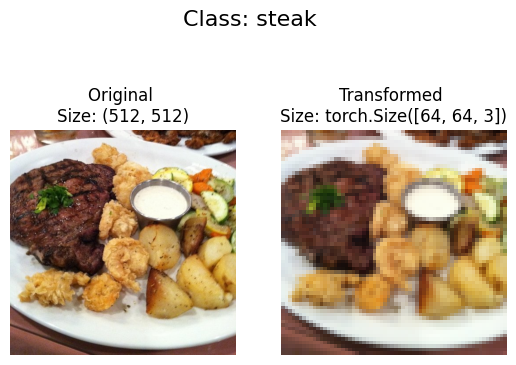

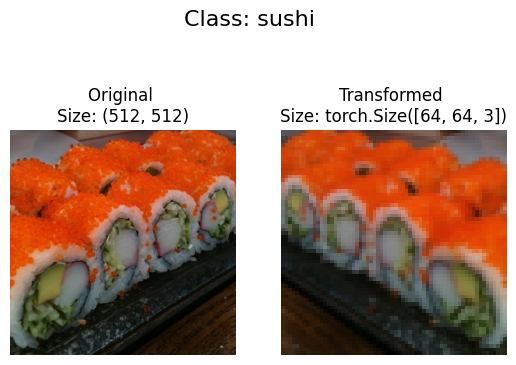

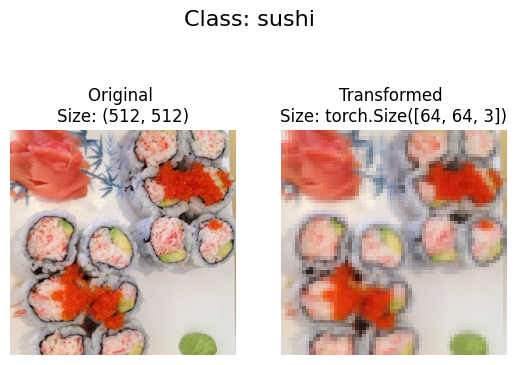

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

### Transform 결과 정리

- `torchvision.transforms`를 사용하여  
  이미지를 텐서로 변환할 수 있게 됨

- 추가로
  - 이미지 크기 조정
  - 방향 변경(좌우 반전)
  도 가능

- 일부 모델은 특정 크기/형태의 이미지를 더 선호함

**이미지 크기와 정보량**

- 일반적으로 이미지 크기가 클수록 더 많은 정보를 포함

- 예시
  - `[256, 256, 3]` 이미지
  - `[64, 64, 3]` 이미지보다  
    → 16배 더 많은 픽셀

- 계산
```text
(256 × 256 × 3) / (64 × 64 × 3) = 16

## 4. Option 1: Loading Image Data Using [`ImageFolder`](https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder)

- 이제 이미지 데이터를 PyTorch에서 사용할 수 있는 `Dataset` 형태로 변환할 단계

**핵심 개념**

- 현재 데이터는 표준 이미지 분류 구조
  - 클래스별 폴더 구조
- 이런 경우 `ImageFolder`를 바로 사용할 수 있음

**ImageFolder란?**

- [`torchvision.datasets.ImageFolder`](https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder)
- 디렉토리 구조 기반으로 자동으로 데이터셋 생성

- 동작 방식
  - 폴더 이름 → 클래스(label)
  - 폴더 내부 이미지 → 데이터

**사용 방법**

- 입력값
  - 이미지 디렉토리 경로 (`train_dir`, `test_dir`)
  - transform (전처리 및 텐서 변환)

**실습 내용**

- `train_dir`, `test_dir`에 대해 `ImageFolder` 적용
- `transform=data_transform` 전달

  - 이미지 → 텐서 변환
  - 크기 조정 및 augmentation 적용

**결과**

- PyTorch에서 바로 사용할 수 있는 `Dataset` 객체 생성
- 이후 `DataLoader`와 함께 사용 가능

In [ ]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


**Dataset 확인 (Inspecting Dataset)**

- PyTorch가 `Dataset`을 정상적으로 인식한 상태

- 이제 데이터셋 내부를 확인해보는 단계

**확인할 항목**

- `classes`
  - 데이터셋에 포함된 클래스 이름 목록

- `class_to_idx`
  - 클래스 이름 → 숫자 인덱스 매핑
  - 예시
    - `{"pizza": 0, "steak": 1, "sushi": 2}`

- 데이터셋 길이 (`len()`)

  - 학습 데이터 개수
    - `len(train_data)`

  - 테스트 데이터 개수
    - `len(test_data)`

**왜 중요한가?**

- 클래스가 제대로 인식되었는지 확인
- 라벨이 올바르게 매핑되었는지 확인
- 데이터 개수가 예상과 일치하는지 검증

**한 줄 요약**

- "데이터셋이 제대로 만들어졌는지 검증하는 단계"

In [ ]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the lengths
len(train_data), len(test_data)

(225, 75)

**이미지와 라벨 확인**

- 데이터셋 구조 확인 완료
- 이제 실제 데이터(이미지 + 라벨)를 확인하는 단계

**확인 방법**

- `Dataset` 객체는 인덱싱(`[]`)을 지원

- 예시
  - `train_data[0]`
  - `test_data[0]`

- 반환값
  - `(image, label)` 형태의 튜플

**구성 요소**

- `image`
  - transform이 적용된 이미지 (Tensor 형태)

- `label`
  - 해당 이미지의 클래스 인덱스 (정수)

**왜 중요한가?**

- 데이터가 올바르게 로드되었는지 확인
- 이미지와 라벨이 제대로 매칭되는지 검증
- 텐서 형태 및 크기 확인 가능

**활용 예시**

- 특정 샘플 확인
- 이미지 시각화
- 라벨 → 클래스 이름 변환 (`class_to_idx` 활용)

**한 줄 요약**

- "Dataset에서 실제 데이터 샘플을 직접 꺼내 확인하는 단계"

In [ ]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

**텐서 이미지 시각화**

- 이미지가 텐서 형태로 변환됨 (shape: `[3, 64, 64]`)
- 라벨은 특정 클래스를 나타내는 정수 형태 (`class_to_idx` 기준)

- `matplotlib`을 사용하여 이미지 텐서를 시각화 가능

- 시각화를 위해 차원 순서를 변경해야 함

**차원 순서**

- 현재: `CHW`
  - (color channels, height, width)

- `matplotlib` 요구 형식: `HWC`
  - (height, width, color channels)

- 해결 방법
  - `permute()`를 사용하여 차원 순서 재배열

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


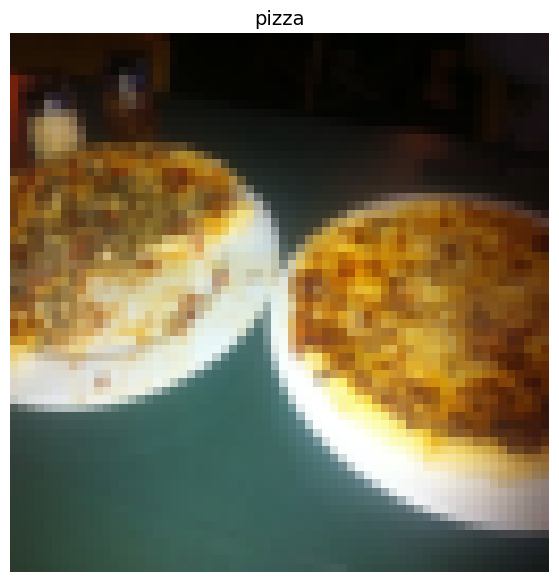

In [ ]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

Notice the image is now more pixelated (less quality).

This is due to it being resized from `512x512` to `64x64` pixels.

The intuition here is that if you think the image is harder to recognize what's going on, chances are a model will find it harder to understand too.

### 4.1 Turn loaded images into `DataLoader`'s

We've got our images as PyTorch `Dataset`'s but now let's turn them into `DataLoader`'s.

We'll do so using [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

Turning our `Dataset`'s into `DataLoader`'s makes them iterable so a model can go through and learn the relationships between samples and targets (features and labels).

To keep things simple, we'll use a `batch_size=1` and `num_workers=1`.

What's `num_workers`?

Good question.

It defines how many subprocesses will be created to load your data.

Think of it like this, the higher value `num_workers` is set to, the more compute power PyTorch will use to load your data.

Personally, I usually set it to the total number of CPUs on my machine via Python's [`os.cpu_count()`](https://docs.python.org/3/library/os.html#os.cpu_count).

This ensures the `DataLoader` recruits as many cores as possible to load data.

> **Note:** There are more parameters you can get familiar with using `torch.utils.data.DataLoader` in the [PyTorch documentation](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [ ]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1, # how many samples per batch?
                              num_workers=1, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False) # don't usually need to shuffle testing data

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x789b3c6e8500>,
 <torch.utils.data.dataloader.DataLoader at 0x789b3c6bc6b0>)

Wonderful!

Now our data is iterable.

Let's try it out and check the shapes.

In [ ]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


We could now use these `DataLoader`'s with a training and testing loop to train a model.

But before we do, let's look at another option to load images (or almost any other kind of data).

## 5. Option 2: Loading Image Data with a Custom `Dataset`

What if a pre-built `Dataset` creator like [`torchvision.datasets.ImageFolder()`](https://pytorch.org/vision/stable/datasets.html#torchvision.datasets.ImageFolder) didn't exist?

Or one for your specific problem didn't exist?

Well, you could build your own.

But wait, what are the pros and cons of creating your own custom way to load `Dataset`'s?

| Pros of creating a custom `Dataset` | Cons of creating a custom `Dataset` |
| ----- | ----- |
| Can create a `Dataset` out of almost anything. | Even though you *could* create a `Dataset` out of almost anything, it doesn't mean it will work. |
| Not limited to PyTorch pre-built `Dataset` functions. | Using a custom `Dataset` often results in writing more code, which could be prone to errors or performance issues. |

To see this in action, let's work towards replicating `torchvision.datasets.ImageFolder()` by subclassing `torch.utils.data.Dataset` (the base class for all `Dataset`'s in PyTorch).

We'll start by importing the modules we need:
* Python's `os` for dealing with directories (our data is stored in directories).
* Python's `pathlib` for dealing with filepaths (each of our images has a unique filepath).
* `torch` for all things PyTorch.
* PIL's `Image` class for loading images.
* `torch.utils.data.Dataset` to subclass and create our own custom `Dataset`.
* `torchvision.transforms` to turn our images into tensors.
* Various types from Python's `typing` module to add type hints to our code.

> **Note:** You can customize the following steps for your own dataset. The premise remains: write code to load your data in the format you'd like it.

In [ ]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

Remember how our instances of `torchvision.datasets.ImageFolder()` allowed us to use the `classes` and `class_to_idx` attributes?

In [ ]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

Let's write a helper function capable of creating a list of class names and a dictionary of class names and their indexes given a directory path.

To do so, we'll:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dictionary of numerical labels, one for each class.

Let's see a small example of step 1 before we write the full function.

In [ ]:
# Setup path for target directory
target_directory = train_dir
print(f"Target directory: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(image_path / "train"))])
print(f"Class names found: {class_names_found}")

Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


Excellent!

How about we turn it into a full function?

In [ ]:
# Make function to find classes in target directory
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory.

    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load classnames from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))

    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
    """
    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if class names not found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

    # 3. Create a dictionary of index labels (computers prefer numerical rather than string labels)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

Looking good!

Now let's test out our `find_classes()` function.

In [ ]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

Woohoo! Looking good!

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

Now we're ready to build our own custom `Dataset`.

We'll build one to replicate the functionality of `torchvision.datasets.ImageFolder()`.

This will be good practice, plus, it'll reveal a few of the required steps to make your own custom `Dataset`.

It'll be a fair bit of a code... but nothing we can't handle!

Let's break it down:
1. Subclass `torch.utils.data.Dataset`.
2. Initialize our subclass with a `targ_dir` parameter (the target data directory) and `transform` parameter (so we have the option to transform our data if needed).
3. Create several attributes for `paths` (the paths of our target images), `transform` (the transforms we might like to use, this can be `None`), `classes` and `class_to_idx` (from our `find_classes()` function).
4. Create a function to load images from file and return them, this could be using `PIL` or [`torchvision.io`](https://pytorch.org/vision/stable/io.html#image) (for input/output of vision data).
5. Overwrite the `__len__` method of `torch.utils.data.Dataset` to return the number of samples in the `Dataset`, this is recommended but not required. This is so you can call `len(Dataset)`.
6. Overwrite the `__getitem__` method of `torch.utils.data.Dataset` to return a single sample from the `Dataset`, this is required.

Let's do it!

In [ ]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None) -> None:

        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg")) # note: you'd have to update this if you've got .png's or .jpeg's
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # 4. Make function to load images
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths)

    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

Woah! A whole bunch of code to load in our images.

This is one of the downsides of creating your own custom `Dataset`'s.

However, now we've written it once, we could move it into a `.py` file such as `data_loader.py` along with some other helpful data functions and reuse it later on.

Before we test out our new `ImageFolderCustom` class, let's create some transforms to prepare our images.

In [ ]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

# Don't augment test data, only reshape
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

Now comes the moment of truth!

Let's turn our training images (contained in `train_dir`) and our testing images (contained in `test_dir`) into `Dataset`'s using our own `ImageFolderCustom` class.

In [ ]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x789b3c59e150>,
 <__main__.ImageFolderCustom at 0x789b3c59e180>)

Hmm... no errors, did it work?

Let's try calling `len()` on our new `Dataset`'s and find the `classes` and `class_to_idx` attributes.

In [ ]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [ ]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [ ]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

`len(test_data_custom) == len(test_data)` and `len(test_data_custom) == len(test_data)` Yes!!!

It looks like it worked.

We could check for equality with the `Dataset`'s made by the `torchvision.datasets.ImageFolder()` class too.

In [ ]:
# Check for equality amongst our custom Dataset and ImageFolder Dataset
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True
True


Ho ho!

Look at us go!

Three `True`'s!

You can't get much better than that.

How about we take it up a notch and plot some random images to test our `__getitem__` override?

### 5.3 Create a function to display random images

> 149. Writing a Helper Function to Visualize Random Images from Our Custom Dataset
; 커스텀 데이터셋에서 무작위 이미지를 시각화하기 위한 헬퍼 함수 작성하기

데이터 탐험가로서 가장 중요한 단계인 **시각화**를 진행할 차례입니다.
`Dataset`의 이미지를 효율적으로 확인할 수 있도록 `display_random_images()` 헬퍼 함수를 생성합니다.

**주요 기능 및 단계:**

1. **매개변수 입력:** `Dataset`, `classes`(타겟 클래스명), `n`(표시할 이미지 수), 랜덤 시드(seed) 수신
2. **개수 제한:** 디스플레이 가독성을 위해 `n`의 최대치를 10으로 제한
3. **재현성 설정:** `seed` 값이 있을 경우, 결과 재현을 위해 랜덤 시드 고정
4. **샘플 추출:** `random.sample()`을 사용하여 플롯할 무작위 샘플 인덱스 리스트 생성
5. **플롯 설정:** `matplotlib`을 이용한 시각화 레이아웃 구성
6. **이미지 출력:** 추출된 인덱스를 반복문으로 순회하며 `matplotlib`으로 이미지 출력
7. **차원 확인:** 시각화를 위해 샘플 이미지의 형상을 **HWC**(높이, 너비, 채널) 포맷으로 변환 및 확인

In [ ]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset, # 시각화할 Pytorch 데이터셋
                          classes: List[str] = None, # class index에 대응하는 리스트
                          n: int = 10, # 표시 할 이미지 개수
                          display_shape: bool = True, # 이미지의 차원 정보 표시 여부
                          seed: int = None): # 랜던 시드값

    # 2. Adjust display if n too high
    if n > 10:
        n = 10 # 10으로 고정
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n) # random.sample()로 데이터셋 전체 범위 내에서 중복 없이 n개의 인덱스 무작위로 선택

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples; 데이터 추출 및 반복문 실행
    for i, targ_sample in enumerate(random_samples_idx): # i = 반복 횟수, targ_sample = 실제 데이터의 인덱스
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1] # dataset 객체를 인덱스로 접근해서 (이미지 텐서, 라벨 숫자) 형태의 튜플 반환
        # 0 = 튜플의 첫 번째 요소인 이미지 데이터 tensor, 1 = 튜플의 두 번째 요소인 정답 index

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0) # pytorch 형식 -> matplotlib H, W, C 형식으로 변환하기

        # Plot adjusted samples
        plt.subplot(1, n, i+1) # subplot: 한 줄에 n개의 이미지 배치
        plt.imshow(targ_image_adjust) # 이미지 출력
        plt.axis("off")
        if classes: # 클래스 이름 및 이미지 차원 정보 이미지 상단에 표시
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

What a good looking function!

Let's test it out first with the `Dataset` we created with `torchvision.datasets.ImageFolder()`.

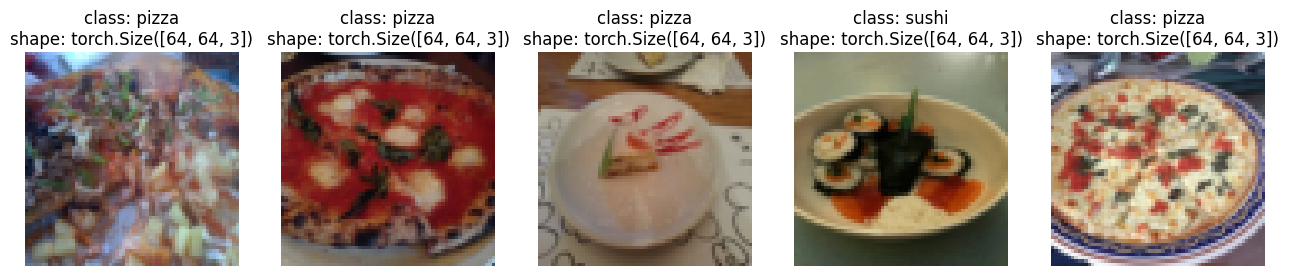

In [ ]:
# Display random images from ImageFolder created Dataset
display_random_images(train_data, # 준비한 학습용 데이터셋 넣기
                      n=5, # 5개 보여주기
                      classes=class_names, # 실제 이름으로 바꾸기
                      seed=None) # 매번 무작위로 이미지 나오게 됨

And now with the `Dataset` we created with our own `ImageFolderCustom`.

For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


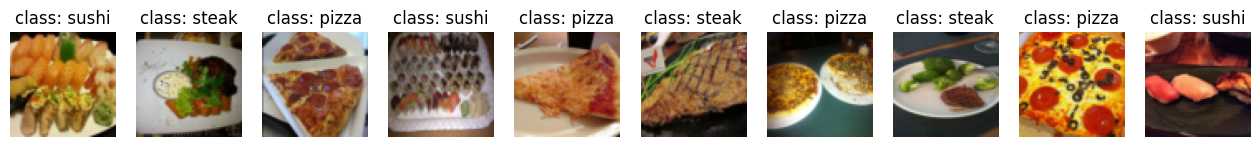

In [ ]:
# Display random images from ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      n=12,
                      classes=class_names,
                      seed=3) # Try setting the seed for reproducible images

Nice!!!

Looks like our `ImageFolderCustom` is working just as we'd like it to.

### 5.4 커스텀 데이터셋을 `DataLoader`로 변환

> **150. Turning Our Custom Datasets Into DataLoaders; 커스텀 데이터셋을 DataLoader로 만들기**

`ImageFolderCustom` 클래스를 활용해 원본 이미지를 `Dataset`(특징 $X$와 라벨 $y$가 매핑된 형태)으로 변환하는 방법을 확인했습니다. 이제 이 커스텀 데이터셋을 학습에 바로 사용할 수 있는 `DataLoader`로 변환할 차례입니다.

**주요 특징 및 단계:**

*   **도구 활용:** PyTorch 표준인 `torch.utils.data.DataLoader()` 사용
*   **호환성 확보:** 직접 만든 커스텀 데이터셋이 `torch.utils.data.Dataset`을 상속받으므로, `DataLoader`와 즉시 연동 가능
*   **작업 절차:** 기존 PyTorch 내장 데이터셋을 사용할 때와 거의 동일한 프로세스 적용
*   **핵심 차이점:** 라이브러리 제공 데이터셋이 아닌, 우리가 **직접 정의한 커스텀 데이터셋 객체**를 인자로 전달함



**핵심 요약:**
1.  **Dataset:** 데이터를 하나씩 꺼내오는 역할 (Item-by-item)
2.  **DataLoader:** 데이터를 묶어서 배치(Batch)로 만들고, 셔플(Shuffle) 등을 수행하여 모델 학습에 투입 가능한 형태로 변환
3.  **결론:** 상속 관계만 잘 지켰다면 커스텀 데이터셋도 `DataLoader`에서 아무 문제 없이 동작함

In [ ]:
# Turn train and test custom Dataset's into DataLoader's
from torch.utils.data import DataLoader # 데이터를 batch 단위로 묶어주는 클래스 가져옴
train_dataloader_custom = DataLoader(dataset=train_data_custom, # 직접 만든 커스텀 훈련 데이터셋 소스로 사용
                                     batch_size=1, # 한 번의 학습 단계(step)에서 모델에 전달할 데이터 개수
                                     num_workers=0, # how many subprocesses to use for data loading? (CPU 코어 개수) (higher = more)
                                     shuffle=True) # shuffle the data? (epoch마다 무작위로 섞음)

test_dataloader_custom = DataLoader(dataset=test_data_custom, # use custom created test Dataset
                                    batch_size=1,
                                    num_workers=0,
                                    shuffle=False) # don't usually need to shuffle testing data

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x789b3ca51760>,
 <torch.utils.data.dataloader.DataLoader at 0x789b3c3562a0>)

Do the shapes of the samples look the same?

In [ ]:
# Get image and label from custom DataLoader
img_custom, label_custom = next(iter(train_dataloader_custom)) # Data loader를 iterable로 변환, next로 배치를 하나씩 꺼냄

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


They sure do!

Let's now take a look at some other forms of data transforms.

## 6. 다양한 형태의 변형 (데이터 증강, Data Augmentation)

> 151. Exploring State of the Art Data Augmentation With Torchvision Transforms

데이터 변형(Transform)에는 이미 살펴본 것 외에도 매우 다양한 종류가 있습니다. 전체 목록은 [`torchvision.transforms` 공식 문서](https://pytorch.org/vision/stable/transforms.html)에서 확인하실 수 있습니다.

### **1. 변형(Transforms)의 목적**
*   **이미지 수정:** 원본 이미지를 텐서(Tensor)로 변환하거나, 특정 크기로 자르기(Crop), 무작위 삭제(Erasing), 무작위 회전(Rotation) 등을 수행합니다.
*   **데이터 증강(Data Augmentation):** 데이터를 인위적으로 변형하여 학습 데이터셋의 다양성을 **인위적으로** 높이는 과정입니다.

### **2. 데이터 증강의 효과**
*   **일반화(Generalization) 능력 향상:** 모델이 데이터의 핵심적인 특징을 더 잘 파악하게 하여, 학습할 때 보지 못한 새로운 데이터에도 유연하게 대처할 수 있도록 만듭니다.
*   다양한 시각적 예시는 PyTorch의 [시각화 예제 페이지](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html)에서 확인 가능합니다.

### **3. 무작위 변형의 힘 (TrivialAugment)**
*   **연구 결과:** 연구에 따르면 사람이 직접 변형 방식을 고르는 것보다 `RandAugment`나 `TrivialAugmentWide` 같은 **무작위 변형** 기법이 일반적으로 더 좋은 성능을 보입니다.
*   **TrivialAugment의 원리:** 준비된 변형 세트 중 몇 가지를 무작위로 선택하고, 정해진 범위 내에서 무작위 강도(Magnitude)로 적용합니다. (강도가 높을수록 변형이 더 강해집니다.)

![trivial augment data augmentation being used for PyTorch state of the art training](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-trivial-augment-being-using-in-PyTorch-resize.png)

*   **실전 사례:** PyTorch 팀은 최신 SOTA(State-of-the-Art, 현재 최고 수준) 비전 모델을 학습시킬 때 이 기법을 핵심 요소로 활용했습니다.



### **4. `TrivialAugmentWide()` 사용법**
*   **핵심 파라미터 (`num_magnitude_bins=31`):** 변형 강도의 범위를 설정합니다. `0`은 변형 없음, `31`은 최대 범위 내에서 가장 강한 변형이 적용될 가능성을 의미합니다.
*   **구현 방법:** 기존처럼 `transforms.Compose()` 안에 포함시켜 간단히 사용할 수 있습니다.

In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([ # 훈련용 변형
    transforms.Resize((224, 224)), # 입력 크기 맞추기
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # how intense -> 이미지를 무작위로 변형 (색산 변경, 회전, 비틀기 등), magnitude bins = 강도 결정
    transforms.ToTensor() # use ToTensor() last to get everything between 0 & 1 시각적 변형은 마지막에 수행
])

# Don't need to perform augmentation on the test data -> 이미지 변형 없이 규격만 맞춤
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

> **참고(Note):** 일반적으로 테스트 세트에는 데이터 증강을 수행하지 않습니다. 데이터 증강의 핵심 아이디어는 학습 세트의 다양성을 **인위적으로** 높여서, 결과적으로 테스트 세트에 대한 예측 성능을 개선하는 것이기 때문입니다.
>
> 하지만 테스트 세트의 이미지도 반드시 **텐서(Tensor)로 변환**해야 합니다. 또한 테스트 이미지의 크기를 학습 이미지와 동일하게 조정하는데, 필요에 따라 다른 크기의 이미지로 추론(Inference)을 진행할 수도 있으나 이는 성능에 영향을 줄 수 있습니다.

학습용 변형(데이터 증강 포함)과 테스트용 변형(데이터 증강 미포함)이 모두 준비되었습니다.

이제 우리가 설정한 데이터 증강이 실제로 어떻게 작동하는지 확인해 봅시다!

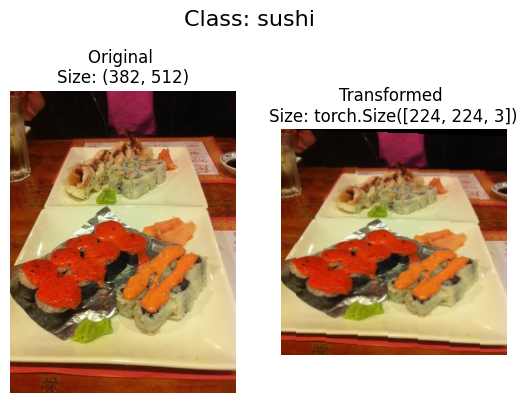

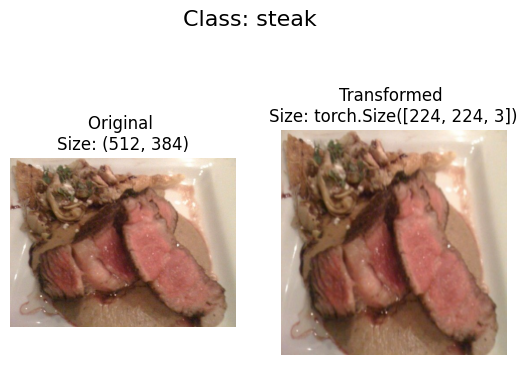

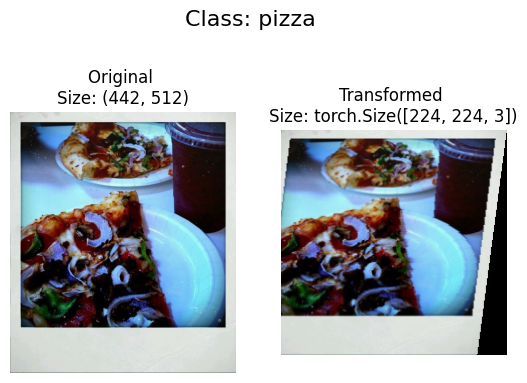

In [ ]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg")) # glob로 하위 폴더 모두 찾기

# Plot random images
plot_transformed_images(
    image_paths=image_path_list, # 이미지 경로 전달
    transform=train_transforms, # TrivialAugmentWide가 포함된 훈련용 변형 적용
    n=3, # 무작위로 3장 뽑기
    seed=None
)

Try running the cell above a few times and seeing how the original image changes as it goes through the transform.

## 7. Model 0: TinyVGG without data augmentation

Alright, we've seen how to turn our data from images in folders to transformed tensors.

Now let's construct a computer vision model to see if we can classify if an image is of pizza, steak or sushi.

To begin, we'll start with a simple transform, only resizing the images to `(64, 64)` and turning them into tensors.

### 7.1 Creating transforms and loading data for Model 0

In [ ]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

Excellent, now we've got a simple transform, let's:
1. Load the data, turning each of our training and test folders first into a `Dataset` with `torchvision.datasets.ImageFolder()`
2. Then into a `DataLoader` using `torch.utils.data.DataLoader()`.
    * We'll set the `batch_size=32` and `num_workers` to as many CPUs on our machine (this will depend on what machine you're using).

In [ ]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

# 2. Turn data into DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of workers
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create DataLoader's
train_dataloader_simple = DataLoader(train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_simple, test_dataloader_simple

Creating DataLoader's with batch size 32 and 2 workers.


(<torch.utils.data.dataloader.DataLoader at 0x789b3c38ba40>,
 <torch.utils.data.dataloader.DataLoader at 0x789b3c425400>)

`DataLoader`'s created!

Let's build a model.

### 7.2 Create TinyVGG model class

In [notebook 03](https://www.learnpytorch.io/03_pytorch_computer_vision/#7-model-2-building-a-convolutional-neural-network-cnn), we used the TinyVGG model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

Let's recreate the same model, except this time we'll be using color images instead of grayscale (`in_channels=3` instead of `in_channels=1` for RGB pixels).

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Dynamically calculate the flattened size for the linear layer
        # For a 64x64 input, it becomes 32x32 after block 1 and 16x16 after block 2
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

> **Note:** One of the ways to speed up deep learning models computing on a GPU is to leverage **operator fusion**.
>
> This means in the `forward()` method in our model above, instead of calling a layer block and reassigning `x` every time, we call each block in succession (see the final line of the `forward()` method in the model above for an example).
>
> This saves the time spent reassigning `x` (memory heavy) and focuses on only computing on `x`.
>
> See [*Making Deep Learning Go Brrrr From First Principles*](https://horace.io/brrr_intro.html) by Horace He for more ways on how to speed up machine learning models.

Now that's a nice looking model!

How about we test it out with a forward pass on a single image?



### 7.3 Try a forward pass on a single image (to test the model)

A good way to test a model is to do a forward pass on a single piece of data.

It's also handy way to test the input and output shapes of our different layers.

To do a forward pass on a single image, let's:
1. Get a batch of images and labels from the `DataLoader`.
2. Get a single image from the batch and `unsqueeze()` the image so it has a batch size of `1` (so its shape fits the model).
3. Perform inference on a single image (making sure to send the image to the target `device`).
4. Print out what's happening and convert the model's raw output logits to prediction probabilities with `torch.softmax()` (since we're working with multi-class data) and convert the prediction probabilities to prediction labels with `torch.argmax()`.

In [ ]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader_simple))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))

# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[0.0578, 0.0634, 0.0351]])

Output prediction probabilities:
tensor([[0.3352, 0.3371, 0.3277]])

Output prediction label:
tensor([1])

Actual label:
2


Wonderful, it looks like our model is outputting what we'd expect it to output.

You can run the cell above a few times and each time have a different image be predicted on.

And you'll probably notice the predictions are often wrong.

This is to be expected because the model hasn't been trained yet and it's essentially guessing using random weights.

### 7.4 Use `torchinfo` to get an idea of the shapes going through our model
> torchinfo를 사용하여 모델을 통과하는 데이터의 형태(Shape) 파악하기

`print(model)`을 통해 모델을 출력하면 우리 모델 내부에서 어떤 일이 일어나고 있는지 대략적인 감을 잡을 수 있습니다. 또한, `forward()` 메서드 안에서 데이터의 형태(Shape)를 직접 출력해볼 수도 있습니다.

하지만 모델로부터 정보를 얻는 가장 유용한 방법 중 하나는 [`torchinfo`](https://github.com/TylerYep/torchinfo) 라이브러리를 사용하는 것입니다.

`torchinfo`의 `summary()` 메서드는 **PyTorch 모델**과 **`input_size`**를 인자로 받아, 텐서가 모델을 통과하며 이동할 때 각 레이어별로 어떤 변화가 일어나는지 요약해서 보여줍니다.

> **참고:** Google Colab을 사용 중이라면, 먼저 `!pip install torchinfo`를 통해 라이브러리를 설치해야 합니다.

---

### 요약 결과 해석 가이드

`summary(model, input_size=[32, 1, 28, 28])`를 실행하면 다음과 같은 정보를 얻을 수 있습니다.

| 항목 | 설명 |
| :--- | :--- |
| **Layer (type)** | 사용된 레이어의 이름과 종류 |
| **Output Shape** | 해당 레이어를 통과한 후의 데이터 차원 (예: `[32, 10, 14, 14]`) |
| **Param #** | 해당 레이어에서 학습되는 가중치(Weights)와 편향(Bias)의 총 개수 |
| **Mult-Adds** | 해당 레이어에서 발생하는 연산량 (모델의 무거움을 측정) |

### `torchinfo`를 쓰는 이유
1. **차원 추적:** `MaxPool2d`를 거치며 $28 \to 14 \to 7$로 줄어드는 과정을 눈으로 직접 확인할 수 있습니다.
2. **Flatten 확인:** 마지막 `Linear` 레이어에 들어가기 전, 데이터가 왜 `490` (10 * 7 * 7)이 되어야 하는지 명확히 보여줍니다.
3. **파라미터 관리:** 모델이 너무 무겁지 않은지, 전체 파라미터 개수를 통해 가늠할 수 있습니다.fo`.

In [ ]:
# Install torchinfo if it's not available, import it if it is
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model_0, input_size=[1, 3, 64, 64]) # 예시 입력 사이즈를 넣어 모델의 테스트 통과 과정을 요약
## 첫 번째 1: Batch Size (여기서는 테스트용으로 1장만 넣음)
## 두 번째 1: Color Channels (MNIST는 흑백이므로 1)
## 28, 28: 이미지 가로세로 크기
## 주의:[1, 3, 64, 64]는 컬러 이미지용 예시

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

### <결과값 요약>

### Summary Statistics
*   **Total params:** 모델이 가진 전체 파라미터 수입니다. (가중치 + 편향의 총합)
*   **Trainable params:** 실제 학습 과정에서 업데이트되는 파라미터입니다. (대부분의 경우 Total params와 같습니다.)
*   **Non-trainable params:** 학습되지 않고 고정된 파라미터입니다. (전이 학습 시 레이어를 얼렸을 때 발생합니다.)
*   **Total mult-adds:** 모델이 데이터 한 장을 처리할 때 수행하는 곱셈 및 덧셈 연산 횟수입니다. 모델의 **연산 부하(무거움)**를 측정하는 지표입니다.
*   **Estimated Total Size (MB):** 모델의 가중치와 입력 데이터가 메모리(VRAM/RAM)를 얼마나 차지하는지 예상한 용량입니다.

---

### TinyVGG (MNIST) 데이터 흐름 예시
| 단계 | Output Shape | 해석 |
| :--- | :--- | :--- |
| **Input** | `[1, 1, 28, 28]` | 1장의 흑백 $28 \times 28$ 이미지가 들어옴 |
| **Conv Block 1** | `[1, 10, 14, 14]` | 채널이 10개로 늘어나고, MaxPool로 크기가 절반($14 \times 14$)이 됨 |
| **Conv Block 2** | `[1, 10, 7, 7]` | 더 세밀한 특징을 추출한 뒤, 다시 크기가 절반($7 \times 7$)이 됨 |
| **Classifier** | `[1, 10]` | 3차원 데이터를 일렬로 펼친 뒤(Flatten), 최종적으로 10개 숫자 점수로 변환 |

### torchinfo.summary() 출력 결과 분석

*   **모델 정보의 종합적 제공**
    *   `torchinfo.summary()`의 출력값은 모델에 대한 방대한 양의 정보를 제공함.
    *   **Total params**: 모델에 포함된 전체 파라미터의 총 개수를 확인할 수 있음.
    *   **Estimated Total Size (MB)**: 모델의 전체 용량(크기)을 파악할 수 있음.

*   **데이터 형태 변화 추적**
    *   특정 입력 크기(`input_size`)의 데이터가 모델을 통과할 때 발생하는 **입력 및 출력 형태(Shape)의 변화**를 확인할 수 있음.

*   **현재 모델의 상태 및 전략**
    *   현재 파라미터 수와 전체 모델 용량은 **낮은(low)** 수준임.
    *   이는 **작은 모델(small model)**로 시작했기 때문임.
    *   추후 필요에 따라 모델의 크기를 언제든지 **키울 수 있음(increase)**.

### 7.5 Create train & test loop functions

> 학습 및 테스트 루프 함수 만들기

데이터와 모델이 준비되었으므로, 이제 학습 데이터로 모델을 훈련시키고 테스트 데이터로 모델을 평가하기 위한 **학습 및 테스트 루프 함수**를 만들 차례임.

*   **함수화(Functionize):** 학습 및 테스트 루프를 재사용할 수 있도록 함수 형태로 구현함.
*   **구현할 세 가지 함수:**
    1.  `train_step()`: 모델, `DataLoader`, 손실 함수, 옵티마이저를 입력받아 데이터를 학습시킴.
    2.  `test_step()`: 모델, `DataLoader`, 손실 함수를 입력받아 데이터를 평가함.
    3.  `train()`: 지정된 에폭(epoch) 동안 `train_step()`과 `test_step()`을 함께 수행하고 결과 딕셔너리를 반환함.

> **참고:** PyTorch 최적화 루프 단계는 [notebook 01](https://www.learnpytorch.io/01_pytorch_workflow/#creating-an-optimization-loop-in-pytorch) 및 [비공식 PyTorch 최적화 루프 송](https://youtu.be/Nutpusq_AFw)에서 다루었으며, [notebook 03](https://www.learnpytorch.io/03_pytorch_computer_vision/#62-functionizing-training-and-test-loops)에서도 유사한 함수를 구축한 바 있음.

#### **train_step() 구축 시작**
`DataLoader`에서 **배치(batch)** 단위로 데이터를 처리하기 때문에, 학습 과정 동안 모델의 손실(loss)과 정확도(accuracy) 값을 누적(각 배치 값을 더함)한 뒤, 반환하기 직전에 최종적으로 조정함.

In [ ]:
# `train_step()` 함수는 단일 에폭(Epoch) 동안 모델을 학습시키고, 전체 배치에 대한 평균 손실(Loss)과 정확도(Accuracy)를 계산하여 반환함.
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # 1. 모델을 학습 모드로 설정
    model.train()

    # 2. 에폭별 학습 손실 및 정확도 누적 변수 초기화
    train_loss, train_acc = 0, 0

    # 3. 데이터 로더에서 배치 단위로 데이터를 가져옴
    for batch, (X, y) in enumerate(dataloader):
        # 데이터를 학습 장치(CPU/GPU)로 이동
        X, y = X.to(device), y.to(device)

        # 1. Forward pass: 모델에 입력을 넣어 예측값 계산
        y_pred = model(X)

        # 2. Loss 계산 및 누적: 예측값과 실제 정답 사이의 손실 측정
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad: 이전 배치의 기울기(gradient) 초기화
        optimizer.zero_grad()

        # 4. Backward pass: 손실에 대한 모델 파라미터의 기울기 계산
        loss.backward()

        # 5. Optimizer step: 계산된 기울기를 바탕으로 가중치 업데이트
        optimizer.step()

        # 정확도(Accuracy) 계산 및 누적
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # 최종 메트릭 계산: 전체 배치 수로 나누어 에폭 당 평균값 산출
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

### test_step() 함수 구축 가이드

*   **진행 상황**: `train_step()` 함수 구현 완료.
*   **다음 단계**: 학습 과정과 유사한 방식으로 `test_step()` 함수를 제작함.

*   **주요 차이점**:
    *   **옵티마이저 미사용**: `test_step()`은 학습이 아닌 평가 단계이므로 옵티마이저를 전달받지 않음.
    *   **경사 하강법 제외**: 가중치를 업데이트할 필요가 없으므로 그래디언트(Gradient) 계산 과정을 수행하지 않음.

*   **평가 최적화 설정**:
    *   **추론 모드 활성화**: 예측 성능 향상과 메모리 효율을 위해 `with torch.inference_mode()` 컨텍스트 매니저 내에서 예측을 수행함.

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval() # 드롭아웃(Dropout)이나 배치 정규화(Batch Norm) 등을 평가용으로 고정

    # 테스트 손실 및 정확도 누적 변수 초기화
    test_loss, test_acc = 0, 0

    # Turn on inference context manager 추론 모드 활성화
    with torch.inference_mode(): # 그래디언트 계산을 비활성화하여 메모리 절약 및 연산 속도 향상
        # DataLoader에서 배치 단위로 데이터를 가져옴
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch 전체 배치 수로 나누어 평균값 산출
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

Excellent!



### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`
> `train_step()`와 `test_step()`을 결합한 `train()` 함수 생성

이제 `train_step()`과 `test_step()` 함수를 하나로 합칠 방법이 필요함.

이를 위해 두 함수를 하나의 `train()` 함수로 묶어(package) 관리함. 이 함수는 모델을 학습시킴과 동시에 평가하는 역할을 수행함.

**구체적인 수행 기능:**
1. 모델, 학습 및 테스트용 `DataLoader`, 옵티마이저, 손실 함수, 그리고 각 단계를 수행할 에폭(epochs) 횟수를 입력받음.
2. `train_loss`, `train_acc`, `test_loss`, `test_acc` 값을 담을 빈 결과 딕셔너리를 생성함 (학습이 진행됨에 따라 이 딕셔너리를 채워나감).
3. 설정된 에폭 수만큼 학습 및 테스트 단계 함수를 반복 실행함.
4. 매 에폭이 끝날 때마다 진행 상황을 출력함.
5. 매 에폭마다 업데이트된 지표로 결과 딕셔너리를 갱신함.
6. 데이터가 모두 채워진 딕셔너리를 반환함.

**진행률 추적:**
* 거쳐온 에폭 횟수를 추적하기 위해 `tqdm.auto`에서 `tqdm`을 임포트함.
* `tqdm`은 파이썬에서 가장 인기 있는 진행률 표시바(progress bar) 라이브러리 중 하나임.
* `tqdm.auto`는 사용자의 컴퓨팅 환경(예: Jupyter Notebook vs. Python 스크립트)에 가장 적합한 형태의 진행률 표시바를 자동으로 결정함.

In [ ]:
from tqdm.auto import tqdm

# 1. 학습 및 테스트 단계에 필요한 다양한 파라미터를 입력받음
def train(model: torch.nn.Module, # 학습시킬 파이토치 모델 (nn.Module 상속 객체)
          train_dataloader: torch.utils.data.DataLoader, # 학습 데이터가 담긴 배치 단위의 로더
          test_dataloader: torch.utils.data.DataLoader, # 평가용 데이터가 담긴 배치 단위의 로더
          optimizer: torch.optim.Optimizer, # 모델의 가중치를 업데이트할 최적화 알고리즘
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(), # 예측값과 정답 사이의 오차를 계산할 손실 함수
          epochs: int = 5): # 전체 데이터셋을 반복해서 학습할 총 횟수

    # 2. 에폭별 지표를 기록할 빈 결과 딕셔너리 생성
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. 설정된 에폭 수만큼 반복 (tqdm: 시각적 진행바 라이브러리)
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model, # test_step: 모델을 평가 모드로 두고 가중치 업데이트 없이 성능만 측정
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary 결과 딕셔너리에 현재 에폭의 지표 추가
        # .item()을 사용하여 텐서에서 숫자 값만 추출해 저장 (메모리 효율 및 리스트 관리용)
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

### 7.7 Train and Evaluate Model 0

Alright, alright, alright we've got all of the ingredients we need to train and evaluate our model.

Time to put our `TinyVGG` model, `DataLoader`'s and `train()` function together to see if we can build a model capable of discerning between pizza, steak and sushi!

Let's recreate `model_0` (we don't need to but we will for completeness) then call our `train()` function passing in the necessary parameters.

To keep our experiments quick, we'll train our model for **5 epochs** (though you could increase this if you want).

As for an **optimizer** and **loss function**, we'll use `torch.nn.CrossEntropyLoss()` (since we're working with multi-class classification data) and `torch.optim.Adam()` with a learning rate of `1e-3` respectively.

To see how long things take, we'll import Python's [`timeit.default_timer()`](https://docs.python.org/3/library/timeit.html#timeit.default_timer) method to calculate the training time.

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1078 | train_acc: 0.2578 | test_loss: 1.1362 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0846 | train_acc: 0.4258 | test_loss: 1.1622 | test_acc: 0.1979
Epoch: 3 | train_loss: 1.1153 | train_acc: 0.2930 | test_loss: 1.1695 | test_acc: 0.1979
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.2891 | test_loss: 1.1343 | test_acc: 0.1979
Epoch: 5 | train_loss: 1.0990 | train_acc: 0.2930 | test_loss: 1.1434 | test_acc: 0.1979
Total training time: 19.645 seconds


Hmm...

It looks like our model performed pretty poorly.

But that's okay for now, we'll keep persevering.

What are some ways you could potentially improve it?

> **Note:** Check out the [*Improving a model (from a model perspective)* section in notebook 02](https://www.learnpytorch.io/02_pytorch_classification/#5-improving-a-model-from-a-model-perspective) for ideas on improving our TinyVGG model.

### 7.8 Plot the loss curves of Model 0

From the print outs of our `model_0` training, it didn't look like it did too well.

But we can further evaluate it by plotting the model's **loss curves**.

**Loss curves** show the model's results over time.

And they're a great way to see how your model performs on different datasets (e.g. training and test).

Let's create a function to plot the values in our `model_0_results` dictionary.

In [ ]:
# Check the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

We'll need to extract each of these keys and turn them into a plot.

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

Okay, let's test our `plot_loss_curves()` function out.

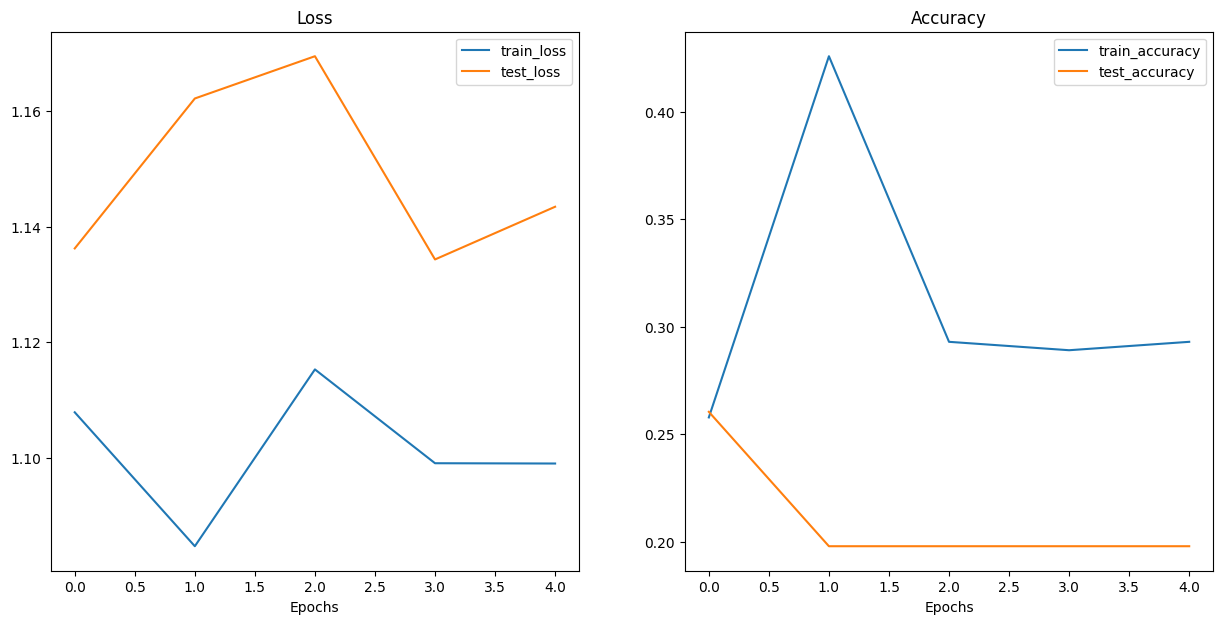

In [ ]:
plot_loss_curves(model_0_results)

Woah.

Looks like things are all over the place...

But we kind of knew that because our model's print out results during training didn't show much promise.

You could try training the model for longer and see what happens when you plot a loss curve over a longer time horizon.

## 8. 이상적인 손실 곡선(Loss Curve)의 특징

> 161. Creating Augmented Training Datasets and ataLoaders for Model 모델을 위한 데이터 증강(Augmented) 훈련 데이터셋 및 데이터로더(DataLoaders) 생성

### 1. 손실 곡선의 역할
*   훈련(Training) 및 테스트(Test) 손실 곡선을 통해 모델의 **과적합(Overfitting)** 여부를 파악할 수 있음

### 2. 주요 상태별 특징
*   **과적합 (Overfitting)**
    *   개념: 모델이 훈련 데이터의 패턴을 너무 과하게 학습하여 새로운 데이터에 일반화되지 못하는 상태
    *   특징: 훈련 세트의 성능이 검증/테스트 세트보다 훨씬 뛰어남 (훈련 손실이 테스트 손실보다 훨씬 낮음)
*   **과소적합 (Underfitting)**
    *   개념: 모델이 데이터의 패턴을 충분히 학습하지 못한 상태
    *   특징: 훈련 및 테스트 손실이 모두 원하는 수준만큼 낮아지지 않음
*   **이상적인 상태 (Ideal)**
    *   특징: 훈련 손실 곡선과 테스트 손실 곡선이 서로 밀접하게 일치하며 하향 안정화됨
    *   의미: 모델이 새로운 데이터에 대해 일반화(Generalization)를 잘하고 있음을 의미

---

### 3. 시각 자료 및 참고 링크

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-loss-curves-overfitting-underfitting-ideal.jpg" alt="different training and test loss curves illustrating overfitting, underfitting and the ideal loss curves" width="800"/>

*   **왼쪽 (과소적합):** 훈련/테스트 손실 곡선이 충분히 내려가지 않은 상태
*   **가운데 (과적합):** 테스트/검증 손실이 훈련 손실보다 높은 상태
*   **오른쪽 (이상적):** 시간이 지남에 따라 두 곡선이 일치하며 모델이 잘 일반화된 상태
*   **참고:** 손실 곡선의 더 다양한 패턴과 해석은 Google의 [손실 곡선 해석 가이드](https://developers.google.com/machine-learning/testing-debugging/metrics/interpretic)에서 확인 가능

### 8.1 과적합(Overfitting)을 해결하는 방법

과적합의 주요 문제는 모델이 훈련 데이터에 *너무 완벽하게* 맞아떨어진다는 점이므로, 이를 "억제하기(reign it in)" 위한 기술을 사용해야 합니다.

과적합을 방지하는 흔한 기술은 [**규제화/정규화(Regularization)**](https://ml-cheatsheet.readthedocs.io/en/latest/regularization.html)로 알려져 있습니다.

저는 이를 "모델을 더 규칙적(regular)으로 만드는 것"이라고 생각하기를 좋아합니다. 즉, *더 많은* 종류의 데이터에 적합할 수 있도록 만드는 것입니다.

과적합을 방지하기 위한 몇 가지 방법에 대해 논의해 보겠습니다.

| **과적합 방지 방법** | **무엇인가요?** |
| ----- | ----- |
| **더 많은 데이터 확보 (Get more data)** | 더 많은 데이터를 가질수록 모델은 새로운 예시에 더 잘 일반화될 수 있는 패턴을 학습할 기회를 더 많이 얻게 됩니다. |
| **모델 단순화 (Simplify your model)** | 현재 모델이 이미 훈련 데이터를 과적합하고 있다면, 모델이 너무 복잡한 것일 수 있습니다. 이는 데이터의 패턴을 너무 잘 학습하여 보지 못한 데이터에 잘 일반화하지 못한다는 것을 의미합니다. 모델을 단순화하는 한 가지 방법은 모델이 사용하는 레이어(layer)의 수를 줄이거나 각 레이어의 은닉 유닛(hidden units) 수를 줄이는 것입니다. |
| **데이터 증강 사용 (Use data augmentation)** | [**데이터 증강(Data augmentation)**](https://developers.google.com/machine-learning/glossary#data-augmentation)은 데이터에 인위적으로 더 많은 다양성을 추가하여 모델이 학습하기 더 어렵게 만드는 방식으로 훈련 데이터를 조작합니다. 모델이 증강된 데이터에서 패턴을 학습할 수 있다면, 보지 못한 데이터에도 더 잘 일반화될 수 있습니다. |
| **전이 학습 사용 (Use transfer learning)** | [**전이 학습(Transfer learning)**](https://developers.google.com/machine-learning/glossary#transfer-learning)은 한 모델이 이미 학습한 패턴(사전 학습된 가중치/pretrained weights라고도 함)을 활용하여 본인의 작업(task)을 위한 기반으로 사용하는 것을 포함합니다. 우리의 경우, 매우 다양한 이미지로 사전 학습된 하나의 컴퓨터 비전 모델을 사용하여 음식 이미지에 더 특화되도록 약간 미세 조정(tweak)할 수 있습니다. |
| **드롭아웃 레이어 사용 (Use dropout layers)** | 드롭아웃 레이어는 신경망에서 은닉층 사이의 연결을 무작위로 제거하여 모델을 효과적으로 단순화할 뿐만 아니라 남아있는 연결들을 더 강력하게 만듭니다. 자세한 내용은 [`torch.nn.Dropout()`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)을 참조하세요. |
| **학습률 감소 사용 (Use learning rate decay)** | 모델이 훈련됨에 따라 학습률(learning rate)을 서서히 감소시키는 개념입니다. 이는 소파 틈새 뒤쪽에 있는 동전을 잡으려고 손을 뻗는 것과 비슷합니다. 동전에 가까워질수록 손을 더 조심스럽게(작게) 움직이게 됩니다. 학습률도 마찬가지로, [**수렴(Convergence)**](https://developers.google.com/machine-learning/glossary#convergence)에 가까워질수록 가중치 업데이트가 더 작아지기를 원할 것입니다. |
| **조기 종료 사용 (Use early stopping)** | [**조기 종료(Early stopping)**](https://developers.google.com/machine-learning/glossary#early_stopping)는 모델이 과적합되기 *전*에 모델 훈련을 중단합니다. 예를 들어, 모델의 손실(loss)이 지난 10 에포크(epoch) 동안 감소하지 않았다면(이 숫자는 임의적임), 여기서 모델 훈련을 중단하고 손실이 가장 낮았던(10 에포크 전의) 모델 가중치를 선택할 수 있습니다. |

과적합을 다루는 방법은 이 외에도 더 많지만, 이것들이 가장 주요한 방법들 중 일부입니다.

점점 더 많은 딥러닝 모델을 구축하기 시작하면, 딥러닝이 데이터의 패턴을 *너무 잘* 학습하기 때문에 과적합을 다루는 것이 딥러닝의 가장 으뜸가는 주요 문제 중 하나라는 것을 깨닫게 될 것입니다.

### 8.2 과소적합(Underfitting)을 해결하는 방법

#### 1. 과소적합의 정의 및 특징
*   **낮은 예측력:** 모델이 과소적합(Underfitting) 상태일 때는 훈련 세트와 테스트 세트 모두에서 예측 능력이 떨어짐
*   **손실 감소 실패:** 본질적으로 과소적합된 모델은 손실(loss) 값을 원하는 수준까지 낮추지 못함
*   **현재 모델 진단:** 지금 당장 우리의 현재 손실 곡선을 보면, `TinyVGG` 모델(`model_0`)은 데이터를 과소적합하고 있는 것으로 판단됨

#### 2. 핵심 해결 아이디어
*   모델의 예측 능력을 **향상(increase)**시키는 것이 과소적합 해결의 핵심 포인트임

#### 3. 과소적합 방지를 위한 주요 방법
| **과소적합 방지 방법** | **무엇인가요?** |
| ----- | ----- |
| **모델에 레이어/유닛 더 추가하기 (Add more layers/units to your model)** | 모델이 과소적합 상태라면, 예측력을 갖추기 위해 데이터의 필요한 패턴/가중치/표현을 *학습*할 수 있는 능력이 부족한 것일 수 있습니다. 모델에 더 많은 예측 능력을 추가하는 한 가지 방법은 은닉층(hidden layers)의 수나 해당 레이어 내의 은닉 유닛(units) 수를 늘리는 것입니다. |
| **학습률 미세 조정하기 (Tweak the learning rate)** | 어쩌면 모델의 학습률(learning rate)이 처음부터 너무 높았을 수도 있습니다. 그래서 매 에포크마다 가중치를 너무 많이 업데이트하려고 하느라, 결과적으로 아무것도 학습하지 못하는 것일 수 있습니다. 이 경우 학습률을 낮추고 어떤 일이 일어나는지 지켜볼 수 있습니다. |
| **전이 학습 사용하기 (Use transfer learning)** | 전이 학습은 과적합과 과소적합을 모두 방지할 수 있습니다. 이는 이전에 이미 작동했던 모델의 패턴을 가져와 본인의 문제에 맞게 조정하는 것을 포함합니다. |
| **더 오래 훈련하기 (Train for longer)** | 때로는 모델이 데이터의 표현을 학습하는 데 더 많은 시간이 필요할 뿐입니다. 소규모 실험에서 모델이 아무것도 배우지 못하는 것처럼 보인다면, 더 많은 에포크(epochs) 동안 훈련하도록 내버려 두는 것이 더 나은 성능으로 이어질 수 있습니다. |
| **규제화/정규화 덜 사용하기 (Use less regularization)** | 어쩌면 과적합을 너무 과하게 방지하려다 보니 모델이 과소적합되었을 수도 있습니다. 규제화 기술의 적용을 조금 줄이면 모델이 데이터에 더 잘 맞아떨어지도록(fit) 도울 수 있습니다. |

### 8.3 과적합(Overfitting)과 과소적합(Underfitting) 사이의 균형

#### 1. 두 개념 사이의 딜레마
*   **만병통치약은 없음:** 앞서 언급한 해결책들이 모든 상황에서 항상 통하는 것은 아님
*   **미세한 경계선 존재:** 두 상태 사이의 균형을 잡는 것은 머신러닝 연구에서 가장 활발히 핵심적으로 다뤄지는 분야임
    *   **과소적합 방지:** 데이터에 모델을 더 잘 맞추려고 노력해야 함
    *   **과적합 방지:** 모델이 너무 과하게 학습하여 현실 세계(새로운 데이터)에서 일반화 성능이 떨어지는 것을 막아야 함
*   **인과관계:** 한쪽 문제를 해결하기 위해 기술을 지나치게 적용하면 역으로 다른 쪽 문제를 유발할 수 있음 (예: 과적합을 너무 막으려다 과소적합 발생)

#### 2. 가장 강력한 해결책: 전이 학습 (Transfer Learning)
*   **개념:** 과적합과 과소적합을 동시에 해결할 수 있는 가장 효과적인 기술 중 하나
*   **장점:** 개발자가 과적합/과소적합 방지 기술을 직접 수작업으로 설계하고 실험하는 수고를 크게 줄여줌
*   **활용 방법:** 나와 유사한 문제 공간에서 이미 검증된 모델의 가중치를 가져와 내 데이터셋에 적용
    *   *참고 가능한 오픈소스 플랫폼:* [paperswithcode.com/sota](https://paperswithcode.com/sota), [Hugging Face models](https://huggingface.co/models)

#### 3. 향후 계획
*   이어지는 다음 노트북 실습을 통해 전이 학습의 강력한 성능을 직접 확인할 예정

## 9. 모델 1: 데이터 증강(Data Augmentation)을 적용한 TinyVGG

### 1. 섹션 개요
*   **새로운 실험:** 이전 모델과 다른 새로운 모델을 시도할 시점임
*   **실험 목적:** 데이터를 다시 로드하고 **데이터 증강(Data Augmentation)**을 적용하여 성능이 얼마나 향상되는지 확인하고자 함

### 2. 변형(Transform) 파이프라인 구축 계획
*   **훈련용 변형 (Training Transform):**
    *   이미지 크기 조정(Resize) 및 텐서 변환(ToTensor)을 수행함
    *   무작위 데이터 증강 기법인 `transforms.TrivialAugmentWide()`를 함께 조합(Compose)하여 구성함
*   **테스트용 변형 (Testing Transform):**
    *   훈련용 변형과 동일하게 처리하되, **데이터 증강 단계만 제외**하고 구성함

---

### 9.1 데이터 증강을 적용한 변형(Transform) 생성

In [ ]:
# 1. TrivialAugment를 포함한 훈련용 전처리/증강 파이프라인 생성
train_transform_trivial_augment = transforms.Compose([
    # 이미지 크기를 64x64 픽셀로 변경 (가로, 세로)
    transforms.Resize((64, 64)),

    # 데이터 증강(Data Augmentation) 적용: 최첨단 자동 증강 기법으로 변형 강도를 31단계로 설정
    transforms.TrivialAugmentWide(num_magnitude_bins=31),

    # PIL 이미지나 NumPy 배열을 PyTorch 텐서(Tensor)로 변환하고 픽셀 값을 0~1 사이로 스케일링
    transforms.ToTensor()
])

# 2. 테스트용 전처리 파이프라인 생성 (학습이 아니므로 데이터 증강은 제외)
test_transform = transforms.Compose([
    # 훈련 데이터와 동일하게 이미지 크기를 64x64 픽셀로 변경
    transforms.Resize((64, 64)),

    # 모델 입력 형식에 맞게 PyTorch 텐서로 변환 (0~1 스케일링 포함)
    transforms.ToTensor()
])

### 9.2 훈련 및 테스트용 데이터셋(Dataset)과 데이터로더(DataLoader) 생성

#### 1. 데이터 파이프라인 구축 계획
*   **데이터셋(`Dataset`) 생성:** `torchvision.datasets.ImageFolder()`를 활용하여 이미지 데이터를 PyTorch 데이터셋 형태로 변환함
*   **데이터로더(`DataLoader`) 생성:** `torch.utils.data.DataLoader()`를 활용하여 데이터셋을 모델 학습에 적합한 배치(Batch) 단위의 반복자(Iterator) 형태로 변환함

#### 2. 변형(Transform) 적용 규칙
*   **훈련용 데이터셋 (Train Dataset):** 앞서 정의한 데이터 증강이 포함된 `train_transform_trivial_augment`를 확실하게 적용함
*   **테스트용 데이터셋 (Test Dataset):** 데이터 증강이 제외된 기본 변형인 `test_transform`을 적용함

In [ ]:
# 1. 이미지 폴더 구조를 PyTorch 데이터셋으로 변환 (훈련 데이터)
# train_dir 경로의 이미지를 읽어오고, 위에서 정의한 데이터 증강(trivial_augment)을 적용함
train_data_augmented = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)

# 2. 이미지 폴더 구조를 PyTorch 데이터셋으로 변환 (테스트 데이터)
# test_dir 경로의 이미지를 읽어오고, 기본 전처리(test_transform)만 적용함
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transform)

# 두 데이터셋 객체의 정보를 출력하여 올바르게 로드되었는지 확인
train_data_augmented, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

1. 훈련 데이터셋 (train_data_augmented) 정보

Number of datapoints: 225: 현재 훈련용 이미지 데이터가 총 225개 로드되었다.

Root location: data/pizza_steak_sushi/train: 이미지를 가져온 기본 폴더 경로다.

ImageFolder 특성상 이 하위 폴더 이름들(pizza, steak, sushi)이 자동으로 클래스(정답 레이블)가 된다.

Transform: Compose(...): 해당 데이터셋의 이미지를 꺼낼 때 적용되는 전처리 스택이다. 앞서 설정한 대로 이미지 크기를 $64 \times 64$로 줄이고, TrivialAugmentWide로 무작위 증강을 거친 뒤, 최종적으로 ToTensor()를 통해 파이프라인이 마쳐짐을 확인할 수 있다.

2. 테스트 데이터셋 (test_data_simple) 정보

Number of datapoints: 75: 모델의 최종 성능을 검증할 테스트용 이미지 데이터가 총 75개 로드되었다.

Root location: data/pizza_steak_sushi/test: 테스트 데이터가 저장된 경로다.

Transform: Compose(...): 테스트셋에는 복잡한 증강 없이 $64 \times 64$ 크기 변환(Resize)과 텐서 변환(ToTensor)만 깔끔하게 적용된 상태다.

*And* we'll make `DataLoader`'s with a `batch_size=32` and with `num_workers` set to the number of CPUs available on our machine (we can get this using Python's `os.cpu_count()`).

In [ ]:
# 데이터셋을 배치 단위로 쪼개주는 DataLoader로 변환
import os
BATCH_SIZE = 32              # 한 번에 처리할 데이터 묶음 크기 설정
NUM_WORKERS = os.cpu_count() # 데이터 로딩에 사용할 CPU 코어 수(최대치) 자동 지정

torch.manual_seed(42)        # 배치 구성 및 셔플 결과의 재현성을 위해 시드 고정

# 훈련용 데이터 로더 생성
train_dataloader_augmented = DataLoader(train_data_augmented, # 증강된 훈련 데이터셋 지정
                                        batch_size=BATCH_SIZE,# 32개씩 묶어서 로드
                                        shuffle=True,         # 학습 효율을 위해 매 에폭마다 데이터 순서 섞음
                                        num_workers=NUM_WORKERS) # CPU 멀티프로세싱 적용

# 테스트용 데이터 로더 생성
test_dataloader_simple = DataLoader(test_data_simple,       # 테스트 데이터셋 지정
                                    batch_size=BATCH_SIZE,   # 32개씩 묶어서 로드
                                    shuffle=False,           # 평가 시에는 데이터 순서를 섞지 않음
                                    num_workers=NUM_WORKERS) # CPU 멀티프로세싱 적용

# 생성된 데이터 로더 객체들 확인
train_dataloader_augmented, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x789b3c21e450>,
 <torch.utils.data.dataloader.DataLoader at 0x789b377e4bc0>)

BATCH_SIZE = 32: 225개의 훈련 데이터를 32개씩 쪼개어 총 8개의 묶음(Batch)으로 나눈다. 마지막 묶음은 남은 1개의 데이터만 담기게 된다.

NUM_WORKERS: CPU가 메모리에서 데이터를 미리 꺼내 GPU에게 넘겨주는 역할을 한다. 코어 수를 최대로 잡았으므로 데이터 로딩 속도가 빨라져 GPU가 노는 시간(Overhead)을 줄인다.

shuffle=True: 모델이 특정 데이터 순서를 외우는 편향을 방지하기 위해 훈련할 때만 켜둔다. 반면 테스트할 때는 순서가 성능에 영향을 주지 않으므로 False로 둔다.

### 9.3 모델 1(Model 1) 구축 및 훈련

#### 1. 데이터 준비 완료
*   모델 학습에 필요한 데이터 로드 및 파이프라인 구축 프로세스가 완료되었음

#### 2. 모델 구축 계획
*   **클래스 재사용:** 새로운 모델인 `model_1`을 빌드하기 위해, 이전에 정의해 두었던 `TinyVGG` 모델 클래스를 그대로 재사용함
*   **디바이스 설정:** 모델 연산의 효율성을 위해 생성된 모델 인스턴스를 타겟 디바이스(CPU 또는 GPU/CUDA)로 확실하게 이동(`to(device)`)시켜 줌

In [ ]:
# TinyVGG 모델 인스턴스 생성 및 설정 장치(GPU/CPU)로 전송
torch.manual_seed(42)  # 모델 가중치 초기화의 재현성을 위해 시드 고정
model_1 = TinyVGG(
    input_shape=3,      # 입력 이미지의 채널 수 (RGB 컬러 이미지이므로 3)
    hidden_units=10,    # 합성곱(Conv) 레이어의 은닉 뉴런(필터) 수
    output_shape=len(train_data_augmented.classes) # 출력 클래스 수 (피자, 스테이크, 스시 총 3개)
).to(device)            # 모델을 연산 장치(CPU 또는 GPU)로 이동

model_1                # 모델의 내부 구조 정보 출력

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

<결과해석>

1. conv_block_1 (첫 번째 특징 추출기)Conv2d(3, 10, ...): 3채널 컬러 이미지를 받아 10개의 특징 지도(Feature Map)를 생성한다. 필터 크기는 $3 \times 3$, 패딩이 1이므로 이미지의 가로·세로 크기는 유지된다. ReLU(): 비선형 활성화 함수로 복잡한 패턴 학습을 돕는다.MaxPool2d(kernel_size=2, stride=2): 가로·세로 크기를 정확히 반으로 줄여 중요한 특징만 남기고 연산량을 축소한다.

2. conv_block_2 (두 번째 특징 추출기)conv_block_1과 구조가 동일하다. 앞서 추출된 10개의 특징을 바탕으로 한 단계 더 추상화된 시각적 특징(테두리, 질감 등)을 10개의 필터로 다시 추출하고, 마지막 맥스풀링을 통해 크기를 또 반으로 줄인다.

3. classifier (최종 분류기)Flatten(...): 2차원 특징 지도를 1차원의 긴 벡터로 쭉 편다.Linear(in_features=2560, out_features=3): 앞선 레이어들을 거치며 압축된 2560개의 특징 값을 받아, 최종적으로 3개의 클래스(피자, 스테이크, 스시)에 대한 예측 점수(Logits)를 출력한다.

#### 3. 모델 학습 및 하이퍼파라미터 설정
*   **모델 준비 완료:** 새 모델(`model_1`)의 아키텍처 설정과 디바이스 배치가 모두 완료되었으며, 본격적인 훈련을 시작할 시점임
*   **코드 재사용:** 이전에 구현해 둔 훈련 루프(`train_step()`), 테스트 루프(`test_step()`), 그리고 이 둘을 결합한 통합 훈련 함수(`train()`)를 그대로 재사용하여 효율성을 높임
*   **훈련 환경 설정:** 기존 `model_0`와 거의 동일한 설정을 유지하되, 오직 데이터 증강이 적용된 `train_dataloader` 파라미터만 변경하여 실험을 진행함
    *   **학습 에포크(Epochs):** 총 5 에포크 동안 훈련을 진행함
    *   **훈련 데이터로더:** `train()` 함수의 인자로 데이터 증강이 적용된 `train_dataloader_augmented`를 전달함
    *   **손실 함수(Loss Function):** 다중 클래스 분류(Multi-class Classification) 문제이므로 `torch.nn.CrossEntropyLoss()`를 사용함
    *   **최적화 알고리즘(Optimizer):** `torch.optim.Adam()`을 사용하며, 학습률(Learning Rate)은 `lr=0.001`로 설정함

In [ ]:
# 하이퍼파라미터 설정 및 모델 학습 시작 단계
torch.manual_seed(42)       # CPU 연산의 무작위성을 고정하여 결과 재현성 확보
torch.cuda.manual_seed(42)  # GPU(CUDA) 연산의 무작위성을 고정하여 결과 재현성 확보

NUM_EPOCHS = 5              # 전체 데이터셋을 총 5번 반복하여 학습하도록 설정

# 손실 함수 및 최적화 알고리즘 설정
loss_fn = nn.CrossEntropyLoss() # 다중 분류를 위한 교차 엔트로피 손실 함수 정의
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001) # Adam 옵티마이저 설정 (학습률 0.001)

# 학습 시간 측정을 위한 타이머 시작
from timeit import default_timer as timer
start_time = timer()        # 현재 시간을 시작 시간으로 기록

# 통합 train 함수를 호출하여 model_1 학습 및 평가 진행
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented, # 증강된 훈련 데이터 로더
                        test_dataloader=test_dataloader_simple,       # 기본 테스트 데이터 로더
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# 타이머 종료 및 총 소요 시간 출력
end_time = timer()          # 현재 시간을 종료 시간으로 기록
print(f"Total training time: {end_time-start_time:.3f} seconds") # 최종 걸린 시간 출력

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1076 | train_acc: 0.2500 | test_loss: 1.1062 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0791 | train_acc: 0.4258 | test_loss: 1.1387 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.0810 | train_acc: 0.4258 | test_loss: 1.1696 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1292 | train_acc: 0.3047 | test_loss: 1.1625 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0899 | train_acc: 0.4258 | test_loss: 1.1482 | test_acc: 0.2604
Total training time: 28.929 seconds


1. 정확도(Accuracy)의 정체 (가장 큰 문제)test_acc가 0.2604(26%)로 완전 고정됨: 클래스가 3개(피자, 스테이크, 스시)일 때 무작위로 찍어도 맞출 확률이 약 33.3%다. 26%라는 것은 모델이 찍는 것보다도 못하며, 5에폭 동안 전혀 발전이 없음을 의미한다.train_acc가 42%까지 반짝 올랐다가 다시 떨어지는 것으로 보아, 훈련 데이터의 아주 단순한 특징 일부만 맴돌고 있다.

2. 손실 함수(Loss)의 요동 및 상승test_loss가 계속 증가함: 에폭 1에서 1.1062였던 테스트 손실이 에폭 3에서 1.1696까지 치솟았다가 에폭 5에서 1.1482로 마감했다. 훈련 손실(train_loss) 역시 내려가지 못하고 1.07 ~ 1.12 사이를 불규칙하게 진동하고 있다.

💡 원인 진단 및 해결 방안

1. 데이터 양 부족 및 과도한 증강

문제점: 전체 훈련 데이터가 225개로 매우 적은 상태에서 TrivialAugmentWide를 적용하여 이미지에 과도한 변형이 일어남 ➡️ 모델이 데이터의 기본 패턴조차 잡지 못함

해결책: 데이터 증강을 제외하고 테스트셋과 동일한 기본 전처리로만 학습을 돌려, 원본 데이터에 대해 과적합(Overfitting)이라도 일어나는지 먼저 확인해야 함

2. 모델 역량 부족 (Underfitting)

문제점: TinyVGG 모델의 은닉 뉴런 수(hidden_units=10)가 너무 적고 층이 얕아 복잡한 이미지 특징을 추출하지 못함

해결책 1: 은닉 뉴런 수를 32나 64로 확장하여 모델의 표현력을 높임해결책

 2: (가장 중요) 최종 출력층 직전에 있는 nn.ReLU()를 제거함 (음수 출력이 전부 0으로 뭉개져 손실 함수 계산과 역전파가 완전히 망가지는 현상 방지)

 3. 부적절한 학습률 (Learning Rate)문제점: Adam 옵티마이저의 기본 학습률(lr=0.001)이 데이터 수나 모델 구조에 비해 너무 커서 손실 함수의 최저점을 찾지 못하고 요동칠 수 있음

 해결책: 학습률을 0.0001($1e-4$) 수준으로 낮춰서 가중치를 더 정밀하게 업데이트함1($1e-4$)로 낮춰서 다시 실행해 본다.

Hmm...

It doesn't look like our model performed very well again.

Let's check out its loss curves.

### 9.4 모델 1(Model 1)의 손실 곡선(Loss Curves) 시각화

*   **결과 저장 완료:** 모델 1의 훈련 및 테스트 결과 데이터가 결과 딕셔너리 형태인 `model_1_results`에 모두 기록 및 저장되었음
*   **시각화 계획:** 이 데이터들을 기존에 정의해 둔 `plot_loss_curves()` 함수에 전달하여, 에포크에 따른 손실(Loss)과 정확도(Accuracy) 추이를 그래프로 그려 확인하고자 함

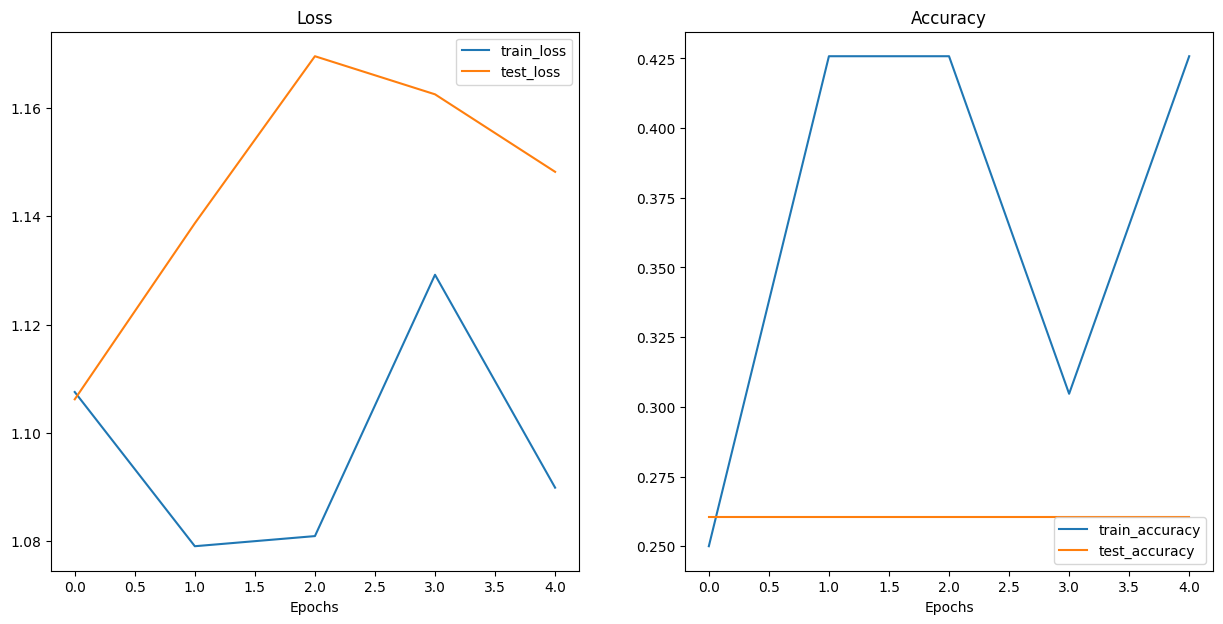

In [ ]:
plot_loss_curves(model_1_results)

**모델 성능에 대한 의문 및 진단**
*   이것들 역시 그리 좋아 보이지는 않습니다...
*   우리의 모델은 **과소적합(underfitting)** 상태일까요, 아니면 **과적합(overfitting)** 상태일까요?
*   그것도 아니라면 둘 다에 해당할까요?
*   이상적으로는 더 높은 정확도(accuracy)와 더 낮은 손실(loss)을 얻고 싶겠지요, 맞습니까?
*   이를 달성하기 위해 여러분이 시도해 볼 수 있는 방법에는 어떤 것들이 있을까요?

## 10. 모델 결과 비교 (Compare model results)

### 1. 현재 상황 진단
*   **낮은 성능:** 현재 우리가 구축한 모델들의 성능이 전반적으로 꽤 저조한 편(quite poorly)인 것은 사실임
*   **분석의 필요성:** 하지만 성능이 좋지 않더라도, 어떤 모델이 어떤 부분에서 더 낫거나 나쁜지 객관적으로 비교 분석하기 위한 코드를 작성하는 것은 매우 중요함

### 2. 진행 계획
*   **데이터 프레임 변환:** 각 모델의 학습 및 테스트 결과가 담긴 딕셔너리 데이터를 활용하여, 분석과 시각화가 용이한 **Pandas DataFrame** 형태로 가장 먼저 변환할 예정임

In [ ]:
# 결과를 분석하기 위해 dictionary 데이터를 Pandas 데이터프레임으로 변환
import pandas as pd
model_0_df = pd.DataFrame(model_0_results) # 첫 번째 모델(model_0)의 에폭별 결과 변환
model_1_df = pd.DataFrame(model_1_results) # 두 번째 모델(model_1)의 에폭별 결과 변환
model_0_df                                # model_0의 학습 테이블 출력

,train_loss,train_acc,test_loss,test_acc
0,1.107836,0.257812,1.136208,0.260417
1,1.084645,0.425781,1.162171,0.197917
2,1.115261,0.292969,1.169489,0.197917
3,1.099015,0.289062,1.134302,0.197917
4,1.098966,0.292969,1.143425,0.197917


<결과 해석>

1. 훈련 정확도(train_acc)와 테스트 정확도(test_acc)의 동반 추락
시작 (0번 에폭): 훈련 정확도 25.7%, 테스트 정확도 26.0%로 시작했다. (3개 클래스 무작위 확률 33.3%보다 낮음)

진행 (1번 에폭): 훈련 정확도가 42.5%로 잠깐 상승했으나, 이때 테스트 정확도는 오히려 19.7%로 떨어졌다.

마무리 (4번 에폭): 결국 마지막까지 테스트 정확도는 19.7%에서 단 1%도 반등하지 못하고 굳어버렸다.

2. 손실 함수(loss)의 정체 및 역주행
train_loss: 1.10 ➡️ 1.08 ➡️ 1.11 ➡️ 1.09 형태로 아래위로 출렁이며 실질적으로 감소하지 못하고 있다.

test_loss: 초기 1.13에서 시작해 에폭 2에는 1.16까지 상승했다가 1.14로 마감했다. 모델이 정답과 점점 더 멀어지고 있다는 뜻이다.

**모델 결과 시각화 계획**

*   이제 우리는 `model_0`와 `model_1` 세트의 결과를 함께 시각화하기 위해, **matplotlib**을 활용한 몇 가지 시각화(그래프 그리기) 코드를 작성할 수 있습니다.

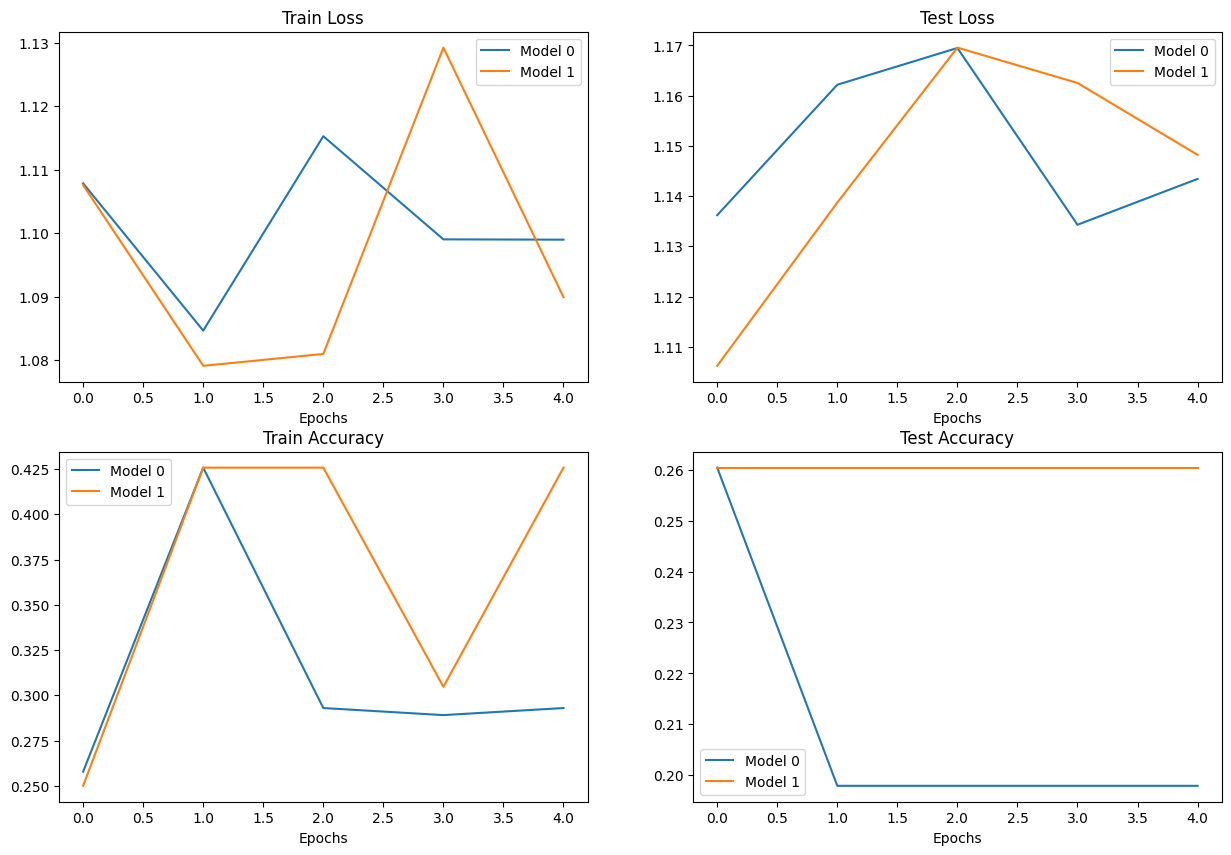

In [ ]:
# 두 모델(Model 0, Model 1)의 학습 성능을 비교 시각화하는 Matplotlib 코드
plt.figure(figsize=(15, 10)) # 가로 15인치, 세로 10인치 크기의 전체 그래프 도화지 생성

epochs = range(len(model_0_df)) # 에폭 수(데이터프레임 행 개수)를 바탕으로 X축 범위 생성 (예: 0, 1, 2, 3, 4)

# 1. 훈련 손실(Train Loss) 비교 그래프 (2x2 배열 중 1번째 칸)
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0") # Model 0의 훈련 손실 선 그래프
plt.plot(epochs, model_1_df["train_loss"], label="Model 1") # Model 1의 훈련 손실 선 그래프
plt.title("Train Loss") # 그래프 제목 설정
plt.xlabel("Epochs")    # X축 이름 설정
plt.legend()            # 범례(Model 0, Model 1 표시) 출력

# 2. 테스트 손실(Test Loss) 비교 그래프 (2x2 배열 중 2번째 칸)
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")  # Model 0의 테스트 손실 선 그래프
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")  # Model 1의 테스트 손실 선 그래프
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# 3. 훈련 정확도(Train Accuracy) 비교 그래프 (2x2 배열 중 3번째 칸)
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")   # Model 0의 훈련 정확도 선 그래프
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")   # Model 1의 훈련 정확도 선 그래프
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# 4. 테스트 정확도(Test Accuracy) 비교 그래프 (2x2 배열 중 4번째 칸)
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")    # Model 0의 테스트 정확도 선 그래프
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")    # Model 1의 테스트 정확도 선 그래프
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend(); # 세미콜론(;)은 불필요한 불라불라 텍스트 출력을 방지하는 팁

**모델 성능 검토 및 개선 방향 질문**

#### 1. 현재 모델 성능 진단 (원문 해석)
*   우리가 만든 두 모델 모두 똑같이 저조한 성능을 보인 것으로 보임
*   아울러 지표가 급격하게 오르내리는 등 다소 불규칙하고 산만하게(sporadic) 움직이는 경향을 나타냄

#### 2. 독자를 향한 질문 (원문 해석)
*   만약 여러분이 다음 모델인 `model_2`를 구축한다면, 성능을 향상시키기 위해 이전과 다르게 어떤 시도를 하시겠습니까?

## 11. Make a prediction on a custom image

If you've trained a model on a certain dataset, chances are you'd like to make a prediction on your own custom data.

In our case, since we've trained a model on pizza, steak and sushi images, how could we use our model to make a prediction on one of our own images?

To do so, we can load an image and then **preprocess it in a way that matches the type of data our model was trained on**.

In other words, we'll have to convert our own custom image to a tensor and make sure it's in the right datatype before passing it to our model.

Let's start by downloading a custom image.

Since our model predicts whether an image contains pizza, steak or sushi, let's download a photo of [my Dad giving two thumbs up to a big pizza from the Learn PyTorch for Deep Learning GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/04-pizza-dad.jpeg).

We download the image using Python's `requests` module.

> **Note:** If you're using Google Colab, you can also upload an image to the current session by going to the left hand side menu -> Files -> Upload to session storage. Beware though, this image will delete when your Google Colab session ends.


In [ ]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

### 11.1 Loading in a custom image with PyTorch

Excellent!

Looks like we've got a custom image downloaded and ready to go at `data/04-pizza-dad.jpeg`.

Time to load it in.

PyTorch's `torchvision` has several input and output ("IO" or "io" for short) methods for reading and writing images and video in [`torchvision.io`](https://pytorch.org/vision/stable/io.html).

Since we want to load in an image, we'll use [`torchvision.io.read_image()`](https://pytorch.org/vision/stable/generated/torchvision.io.read_image.html#torchvision.io.read_image).

This method will read a JPEG or PNG image and turn it into a 3 dimensional RGB or grayscale `torch.Tensor` with values of datatype `uint8` in range `[0, 255]`.

Let's try it out.

In [ ]:
import torchvision

# Read in custom image
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

# Print out image data
print(f"Custom image tensor:\n{custom_image_uint8}\n")
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image tensor:
tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 4032, 3024])

Custom image dty

Nice! Looks like our image is in tensor format, however, is this image format compatible with our model?

Our `custom_image` tensor is of datatype `torch.uint8` and its values are between `[0, 255]`.

But our model takes image tensors of datatype `torch.float32` and with values between `[0, 1]`.

So before we use our custom image with our model, **we'll need to convert it to the same format as the data our model is trained on**.

If we don't do this, our model will error.

In [ ]:
import torchvision.transforms as transforms

# 1. Load image and convert to float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255.

# 2. Resize the image to (64, 64) as the model expects
resize_transform = transforms.Resize((64, 64))
custom_image_resized = resize_transform(custom_image)

# 3. Add batch dimension [C, H, W] -> [1, C, H, W]
custom_image_batch = custom_image_resized.unsqueeze(dim=0)

# 4. Make a prediction
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_batch.to(device))

print(f"Prediction logits: {custom_image_pred}")

Prediction logits: tensor([[ 0.1188,  0.0339, -0.1486]])


If we try to make a prediction on an image in a different datatype to what our model was trained on, we get an error like the following:

> `RuntimeError: Input type (torch.cuda.ByteTensor) and weight type (torch.cuda.FloatTensor) should be the same`

Let's fix this by converting our custom image to the same datatype as what our model was trained on (`torch.float32`).

In [ ]:
# Load in custom image and convert the tensor values to float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)

# Divide the image pixel values by 255 to get them between [0, 1]
custom_image = custom_image / 255.

# Print out image data
print(f"Custom image tensor:\n{custom_image}\n")
print(f"Custom image shape: {custom_image.shape}\n")
print(f"Custom image dtype: {custom_image.dtype}")

Custom image tensor:
tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..

### 11.2 Predicting on custom images with a trained PyTorch model

Beautiful, it looks like our image data is now in the same format our model was trained on.

Except for one thing...

It's `shape`.

Our model was trained on images with shape `[3, 64, 64]`, whereas our custom image is currently `[3, 4032, 3024]`.

How could we make sure our custom image is the same shape as the images our model was trained on?

Are there any `torchvision.transforms` that could help?

Before we answer that question, let's plot the image with `matplotlib` to make sure it looks okay, remember we'll have to permute the dimensions from `CHW` to `HWC` to suit `matplotlib`'s requirements.

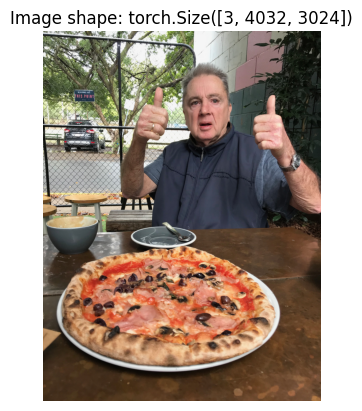

In [ ]:
# Plot custom image
plt.imshow(custom_image.permute(1, 2, 0)) # need to permute image dimensions from CHW -> HWC otherwise matplotlib will error
plt.title(f"Image shape: {custom_image.shape}")
plt.axis(False);

Two thumbs up!

Now how could we get our image to be the same size as the images our model was trained on?

One way to do so is with `torchvision.transforms.Resize()`.

Let's compose a transform pipeline to do so.

In [ ]:
# Create transform pipleine to resize image
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out original shape and new shape
print(f"Original shape: {custom_image.shape}")
print(f"New shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 4032, 3024])
New shape: torch.Size([3, 64, 64])


Woohoo!

Let's finally make a prediction on our own custom image.

In [ ]:
# 모델을 평가 모드로 설정
model_1.eval()

with torch.inference_mode():
    # 1. 배치 차원 추가: [3, 64, 64] -> [1, 3, 64, 64]
    custom_image_with_batch = custom_image_transformed.unsqueeze(dim=0)

    # 2. 데이터를 모델과 동일한 장치(device)로 이동시킨 후 예측 수행
    custom_image_pred = model_1(custom_image_with_batch.to(device))

print(f"예측 결과(Logits): {custom_image_pred}")

예측 결과(Logits): tensor([[ 0.1188,  0.0339, -0.1486]])


Oh my goodness...

Despite our preparations our custom image and model are on different devices.

And we get the error:

> `RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument weight in method wrapper___slow_conv2d_forward)`

Let's fix that by putting our `custom_image_transformed` on the target device.

In [ ]:
# Re-initialize model_1 to apply the fix
model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names)).to(device)
model_1.eval()

with torch.inference_mode():
    # Add batch dimension and move to device
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

# Convert to probabilities
custom_image_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_label = torch.argmax(custom_image_probs, dim=1)

print(f"Prediction: {class_names[custom_image_label]}")
print(f"Confidence: {custom_image_probs.max():.4f}")

Prediction: sushi
Confidence: 0.3404


What now?

It looks like we're getting a shape error.

Why might this be?

We converted our custom image to be the same size as the images our model was trained on...

Oh wait...

There's one dimension we forgot about.

The batch size.

Our model expects image tensors with a batch size dimension at the start (`NCHW` where `N` is the batch size).

Except our custom image is currently only `CHW`.

We can add a batch size dimension using `torch.unsqueeze(dim=0)` to add an extra dimension our image and *finally* make a prediction.

Essentially we'll be telling our model to predict on a single image (an image with a `batch_size` of 1).

In [ ]:
model_1.eval()
with torch.inference_mode():
    # Add an extra dimension to image
    custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)

    # Print out different shapes
    print(f"Custom image transformed shape: {custom_image_transformed.shape}")
    print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")

    # Make a prediction on image with an extra dimension
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

Custom image transformed shape: torch.Size([3, 64, 64])
Unsqueezed custom image shape: torch.Size([1, 3, 64, 64])


Yes!!!

It looks like it worked!

> **Note:** What we've just gone through are three of the classical and most common deep learning and PyTorch issues:
> 1. **Wrong datatypes** - our model expects `torch.float32` where our original custom image was `uint8`.
> 2. **Wrong device** - our model was on the target `device` (in our case, the GPU) whereas our target data hadn't been moved to the target `device` yet.
> 3. **Wrong shapes** - our model expected an input image of shape `[N, C, H, W]` or `[batch_size, color_channels, height, width]` whereas our custom image tensor was of shape `[color_channels, height, width]`.
>
> Keep in mind, these errors aren't just for predicting on custom images.
>
> They will be present with almost every kind of data type (text, audio, structured data) and problem you work with.

Now let's take a look at our model's predictions.

In [ ]:
custom_image_pred

tensor([[-0.0011,  0.0021,  0.0323]])

Alright, these are still in *logit form* (the raw outputs of a model are called logits).

Let's convert them from logits -> prediction probabilities -> prediction labels.

In [ ]:
# Print out prediction logits
print(f"Prediction logits: {custom_image_pred}")

# Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
print(f"Prediction probabilities: {custom_image_pred_probs}")

# Convert prediction probabilities -> prediction labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
print(f"Prediction label: {custom_image_pred_label}")

Prediction logits: tensor([[-0.0011,  0.0021,  0.0323]])
Prediction probabilities: tensor([[0.3293, 0.3303, 0.3404]])
Prediction label: tensor([2])


Alright!

Looking good.

But of course our prediction label is still in index/tensor form.

We can convert it to a string class name prediction by indexing on the `class_names` list.

In [ ]:
# Find the predicted label
custom_image_pred_class = class_names[custom_image_pred_label.cpu()] # put pred label to CPU, otherwise will error
custom_image_pred_class

'sushi'

Wow.

It looks like the model gets the prediction right, even though it was performing poorly based on our evaluation metrics.

> **Note:** The model in its current form will predict "pizza", "steak" or "sushi" no matter what image it's given. If you wanted your model to predict on a different class, you'd have to train it to do so.

But if we check the `custom_image_pred_probs`, we'll notice that the model gives almost equal weight (the values are similar) to every class.

In [ ]:
# The values of the prediction probabilities are quite similar
custom_image_pred_probs

tensor([[0.3293, 0.3303, 0.3404]])

Having prediction probabilities this similar could mean a couple of things:
1. The model is trying to predict all three classes at the same time (there may be an image containing pizza, steak and sushi).
2. The model doesn't really know what it wants to predict and is in turn just assigning similar values to each of the classes.

Our case is number 2, since our model is poorly trained, it is basically *guessing* the prediction.

### 11.3 Putting custom image prediction together: building a function

Doing all of the above steps every time you'd like to make a prediction on a custom image would quickly become tedious.

So let's put them all together in a function we can easily use over and over again.

Specifically, let's make a function that:
1. Takes in a target image path and converts to the right datatype for our model (`torch.float32`).
2. Makes sure the target image pixel values are in the range `[0, 1]`.
3. Transforms the target image if necessary.
4. Makes sure the model is on the target device.
5. Makes a prediction on the target image with a trained model (ensuring the image is the right size and on the same device as the model).
6. Converts the model's output logits to prediction probabilities.
7. Converts the prediction probabilities to prediction labels.
8. Plots the target image alongside the model prediction and prediction probability.

A fair few steps but we've got this!

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device: torch.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""

    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255.

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

What a nice looking function, let's test it out.

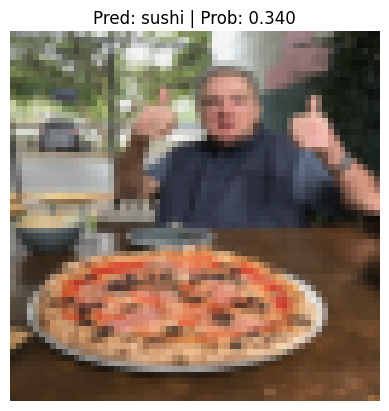

In [ ]:
# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)

### 11.4 최종 예측 결과 해석 및 확률 변환

모델의 출력값은 로짓(Logits) 형태이므로, 이를 사람이 이해할 수 있는 확률로 변환하고 최종 클래스를 확정합니다.

In [ ]:
# 1. 로짓을 확률로 변환 (Softmax)
prediction_probs = torch.softmax(custom_image_pred, dim=1)

# 2. 가장 높은 확률의 인덱스 추출
prediction_label = torch.argmax(prediction_probs, dim=1)

# 3. 인덱스를 클래스 이름으로 매핑
prediction_class = class_names[prediction_label.cpu().item()]

print(f"최종 예측 클래스: {prediction_class}")
print(f"클래스별 확률: {prediction_probs}")
print(f"최대 확률값: {torch.max(prediction_probs).item():.4f}")

최종 예측 클래스: sushi
클래스별 확률: tensor([[0.3293, 0.3303, 0.3404]])
최대 확률값: 0.3404


Two thumbs up again!

Looks like our model got the prediction right just by guessing.

This won't always be the case with other images though...

The image is pixelated too because we resized it to `[64, 64]` using `custom_image_transform`.

> **Exercise:** Try making a prediction with one of your own images of pizza, steak or sushi and see what happens.

## Main takeaways

We've covered a fair bit in this module.

Let's summarise it with a few dot points.

* PyTorch has many in-built functions to deal with all kinds of data, from vision to text to audio to recommendation systems.
* If PyTorch's built-in data loading functions don't suit your requirements, you can write code to create your own custom datasets by subclassing `torch.utils.data.Dataset`.
* `torch.utils.data.DataLoader`'s in PyTorch help turn your `Dataset`'s into iterables that can be used when training and testing a model.
* A lot of machine learning is dealing with the balance between **overfitting** and **underfitting** (we discussed different methods for each above, so a good exercise would be to research more and writing code to try out the different techniques).
* Predicting on your own custom data with a trained model is possible, as long as you format the data into a similar format to what the model was trained on. Make sure you take care of the three big PyTorch and deep learning errors:
    1. **Wrong datatypes** - Your model expected `torch.float32` when your data is `torch.uint8`.
    2. **Wrong data shapes** - Your model expected `[batch_size, color_channels, height, width]` when your data is `[color_channels, height, width]`.
    3. **Wrong devices** - Your model is on the GPU but your data is on the CPU.

## Exercises

All of the exercises are focused on practicing the code in the sections above.

You should be able to complete them by referencing each section or by following the resource(s) linked.

All exercises should be completed using [device-agnostic code](https://pytorch.org/docs/stable/notes/cuda.html#device-agnostic-code).

**Resources:**
* [Exercise template notebook for 04](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb)
* [Example solutions notebook for 04](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/04_pytorch_custom_datasets_exercise_solutions.ipynb) (try the exercises *before* looking at this)

1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.
2. Recreate the data loading functions we built in sections 1, 2, 3 and 4. You should have train and test `DataLoader`'s ready to use.
3. Recreate `model_0` we built in section 7.
4. Create training and testing functions for `model_0`.
5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
    * Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer.
6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?
7. Double the data you're using with your model and train it for 20 epochs, what happens to the results?
    * **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
    * You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.
8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) and share your prediction.
    * Does the model you trained in exercise 7 get it right?
    * If not, what do you think you could do to improve it?

## Extra-curriculum

* To practice your knowledge of PyTorch `Dataset`'s and `DataLoader`'s through PyTorch [datasets and dataloaders tutorial notebook](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).
* Spend 10-minutes reading the [PyTorch `torchvision.transforms` documentation](https://pytorch.org/vision/stable/transforms.html).
    * You can see demos of transforms in action in the [illustrations of transforms tutorial](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html).
* Spend 10-minutes reading the PyTorch [`torchvision.datasets` documentation](https://pytorch.org/vision/stable/datasets.html).
    * What are some datasets that stand out to you?
    * How could you try building a model on these?
* [TorchData is currently in beta](https://pytorch.org/data/beta/index.html) (as of April 2022), it'll be a future way of loading data in PyTorch, but you can start to check it out now.
* To speed up deep learning models, you can do a few tricks to improve compute, memory and overhead computations, for more read the post [*Making Deep Learning Go Brrrr From First Principles*](https://horace.io/brrr_intro.html) by Horace He.